# 🔬 SOLUCIÓN DEFINITIVA: Conv3D Autoencoder Espaciotemporal

## Problema identificado en 03c

**Las variables están fragmentadas temporalmente:**
```
climate_cdd_decadal_mean_2020
climate_cdd_decadal_mean_2030
climate_cdd_decadal_mean_2040
...
climate_cdd_decadal_max_2020
climate_cdd_decadal_max_2030
```

**Consecuencia:** El modelo trata cada timestep como una variable independiente, sin capturar patrones de evolución temporal.

**Variables discriminantes resultantes:** `mean_2040`, `max_2030` (sin sentido conceptual)

---

## Solución: Autoencoder Conv3D Espaciotemporal

**Organización de datos:** `(n_scenarios, lat, lon, time, variables_base)`

- **Espacial (lat, lon):** Captura vecindad geográfica con Conv3D
- **Temporal (time):** Captura evolución 2020→2030→...→2080 con Conv3D
- **Variables base:** CDD, Rx1day, Tmax, Prcptot (sin sufijos temporales)

**Arquitectura:**
```
Input: (3, 24, 42, n_timesteps, n_vars_base)
       ↓
Conv3D(32, kernel=(3,3,3)) → MaxPool3D(2,2,2)
       ↓
Conv3D(64, kernel=(3,3,3)) → MaxPool3D(2,2,2)
       ↓
Flatten → Dense(latent_dim)
       ↓
Dense → Reshape → Conv3DTranspose → UpSampling3D → Conv3DTranspose
       ↓
Output: (3, 24, 42, n_timesteps, n_vars_base)
```

**Ventajas esperadas:**
- ✅ Variables discriminantes con sentido: "CDD", "Rx1day", "Tmax_mean" (sin sufijos temporales)
- ✅ Captura patrones de evolución temporal (tendencias, aceleraciones)
- ✅ Mantiene coherencia espacial (Moran's I > 0.3)
- ✅ Embeddings interpretables: reflejan trayectorias climáticas

---

## Workflow

1. **Cargar datos crudos** por escenario (train+val+test)
2. **Reorganizar features** de flat → `(lat, lon, time, vars_base)`
   - Identificar variables únicas (ej: "climate_cdd_decadal_mean")
   - Extraer timesteps de sufijos (_2020, _2030, ...)
   - Stack temporal: crear dimensión time
3. **Normalizar** por variable base (no por timestep)
4. **Construir Conv3D Autoencoder multimodelo**
5. **Entrenar** con todos los escenarios
6. **Extraer embeddings espaciotemporales**
7. **Clustering** sobre embeddings por píxel
8. **Validar** Moran's I y variables discriminantes


## Paso 1: Imports y configuración

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import json
import re
from datetime import datetime
from collections import defaultdict

# Deep learning
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, LeakyReLU, Dropout, Flatten, Reshape,
    Conv3D, Conv3DTranspose, MaxPooling3D, UpSampling3D, BatchNormalization,
    Cropping3D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Spatial
from scipy.spatial.distance import cdist

# Config
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
np.random.seed(42)
tf.random.set_seed(42)

# Verificar GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ GPU disponible: {gpus[0].name}")
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(f"⚠️  Error configurando GPU: {e}")
else:
    print("⚠️  Ejecutando en CPU")

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")

✅ GPU disponible: /physical_device:GPU:0
TensorFlow version: 2.19.0
NumPy version: 1.26.4


In [12]:
# Configuración de rutas
BASE_DIR = Path('/home/aninotna/magister/tesis/justh2_pipeline')
TENSORS_DIR = BASE_DIR / 'data' / 'autoencoder_tensors'
RESULTS_DIR = BASE_DIR / 'data' / 'autoencoder_results'
MODEL_DIR = BASE_DIR / 'data' / 'autoencoder_trained' / 'spatiotemporal_conv3d'
PLOTS_DIR = BASE_DIR / 'plots' / 'autoencoder_spatiotemporal'

# Crear directorios
MODEL_DIR.mkdir(exist_ok=True, parents=True)
PLOTS_DIR.mkdir(exist_ok=True, parents=True)

# Configuración multimodelo Conv3D
MODELS_CONFIG = {
    'Conv3D_A': {
        'filters_list': [32, 64],
        'latent_dim': 10,
        'description': 'Baseline 2 layers'
    },
    'Conv3D_B': {
        'filters_list': [32, 64, 128],
        'latent_dim': 15,
        'description': 'Optimal 3 layers'
    },
    'Conv3D_C': {
        'filters_list': [32, 64, 128, 256],
        'latent_dim': 20,
        'description': 'Extended 4 layers'
    }
}

# Parámetros de entrenamiento
TRAIN_CONFIG = {
    'batch_size': 2,  # Solo 3 escenarios, batch pequeño
    'epochs': 300,
    'learning_rate': 1e-3,
    'patience': 30,
    'min_delta': 1e-5,
    'validation_split': 0.33,  # 1 escenario para validación
    'seed': 42
}

MODE = 'test'
SCENARIOS = ['ssp245', 'ssp370', 'ssp585']

print("="*80)
print("CONFIGURACIÓN CONV3D AUTOENCODER ESPACIOTEMPORAL")
print("="*80)
print(f"\n📁 Directorios:")
print(f"   Tensores: {TENSORS_DIR}")
print(f"   Modelos: {MODEL_DIR}")
print(f"   Plots: {PLOTS_DIR}")
print(f"\n🧠 Modelos Conv3D:")
for name, config in MODELS_CONFIG.items():
    print(f"   - {name}: {config['description']}")
    print(f"     Filters: {config['filters_list']}, Latent: {config['latent_dim']}")
print(f"\n⚙️  Config entrenamiento:")
for key, val in TRAIN_CONFIG.items():
    print(f"   {key}: {val}")
print("="*80)

CONFIGURACIÓN CONV3D AUTOENCODER ESPACIOTEMPORAL

📁 Directorios:
   Tensores: /home/aninotna/magister/tesis/justh2_pipeline/data/autoencoder_tensors
   Modelos: /home/aninotna/magister/tesis/justh2_pipeline/data/autoencoder_trained/spatiotemporal_conv3d
   Plots: /home/aninotna/magister/tesis/justh2_pipeline/plots/autoencoder_spatiotemporal

🧠 Modelos Conv3D:
   - Conv3D_A: Baseline 2 layers
     Filters: [32, 64], Latent: 10
   - Conv3D_B: Optimal 3 layers
     Filters: [32, 64, 128], Latent: 15
   - Conv3D_C: Extended 4 layers
     Filters: [32, 64, 128, 256], Latent: 20

⚙️  Config entrenamiento:
   batch_size: 2
   epochs: 300
   learning_rate: 0.001
   patience: 30
   min_delta: 1e-05
   validation_split: 0.33
   seed: 42


## Paso 2: Cargar metadatos espaciales

In [13]:
print("="*80)
print("CARGANDO METADATOS ESPACIALES")
print("="*80)

# Cargar metadata
metadata_file = TENSORS_DIR / f'metadata_{MODE}.pkl'
with open(metadata_file, 'rb') as f:
    metadata = pickle.load(f)

spatial_info = metadata['spatial_info']
lat_coords = spatial_info['lat']
lon_coords = spatial_info['lon']
grid_shape = spatial_info['grid_shape']
MASK = metadata['mask']

n_lat, n_lon = grid_shape
n_pixels_valid = MASK.sum()

print(f"\n📐 Información espacial:")
print(f"   Grid shape: {grid_shape} (lat={n_lat}, lon={n_lon})")
print(f"   Píxeles totales: {n_lat * n_lon}")
print(f"   Píxeles válidos: {n_pixels_valid}")
print(f"   Lat range: [{lat_coords.min():.2f}, {lat_coords.max():.2f}]")
print(f"   Lon range: [{lon_coords.min():.2f}, {lon_coords.max():.2f}]")

print("\n" + "="*80)

CARGANDO METADATOS ESPACIALES

📐 Información espacial:
   Grid shape: (24, 42) (lat=24, lon=42)
   Píxeles totales: 1008
   Píxeles válidos: 661
   Lat range: [-33.33, -32.17]
   Lon range: [-71.97, -69.93]



## Paso 3: CLAVE - Reorganizar features de flat a temporal

**Transformación:**
```
Antes (03c): 293 features flat
  - climate_cdd_decadal_mean_2020
  - climate_cdd_decadal_mean_2030
  - climate_cdd_decadal_mean_2040
  - climate_cdd_decadal_std_2020
  - ...

Después (03d): (n_timesteps, n_vars_base)
  - Timesteps: [2020, 2030, 2040, 2050, 2060, 2070, 2080]
  - Variables base: climate_cdd_decadal_mean, climate_cdd_decadal_std, ...
  - Shape final: (lat, lon, 7, n_vars_base)
```

In [14]:
print("="*80)
print("PASO 1: CARGAR FEATURES Y ANALIZAR ESTRUCTURA TEMPORAL")
print("="*80)

# Cargar un ejemplo para analizar features
npz_file = TENSORS_DIR / f'tensors_{SCENARIOS[0]}_splits_{MODE}.npz'
data = np.load(npz_file)
X_sample = data['X_train']

# Si hay archivo de metadata con nombres de features
if 'feature_names' in metadata:
    feature_names = metadata['feature_names']
else:
    # Generar nombres genéricos
    feature_names = [f'feature_{i}' for i in range(X_sample.shape[1])]

print(f"\n📊 Features originales: {len(feature_names)}")
print(f"   Primeras 10:")
for i in range(min(10, len(feature_names))):
    print(f"      {i}: {feature_names[i]}")

# Identificar patrón temporal en nombres
# Buscar sufijos _YYYY (ej: _2020, _2030)
temporal_pattern = re.compile(r'(.+)_(\d{4})$')

# Diccionario para agrupar variables base
var_base_dict = defaultdict(list)

for feat_name in feature_names:
    match = temporal_pattern.match(feat_name)
    if match:
        var_base = match.group(1)  # Nombre sin año
        year = int(match.group(2))  # Año
        var_base_dict[var_base].append((year, feat_name))
    else:
        # Variables sin sufijo temporal (ej: landuse_restricted)
        var_base_dict[feat_name].append((None, feat_name))

print(f"\n🔍 Análisis de estructura temporal:")
print(f"   Variables base únicas: {len(var_base_dict)}")

# Identificar timesteps únicos
all_years = set()
for var_base, year_feat_list in var_base_dict.items():
    for year, _ in year_feat_list:
        if year is not None:
            all_years.add(year)

timesteps = sorted(list(all_years)) if all_years else []
n_timesteps = len(timesteps)

print(f"   Timesteps detectados: {timesteps}")
print(f"   Número de timesteps: {n_timesteps}")

# Separar variables temporales y estáticas
temporal_vars = {k: v for k, v in var_base_dict.items() if any(y is not None for y, _ in v)}
static_vars = {k: v for k, v in var_base_dict.items() if all(y is None for y, _ in v)}

print(f"\n📅 Variables temporales: {len(temporal_vars)}")
print(f"   Ejemplos:")
for i, (var_base, year_feat_list) in enumerate(list(temporal_vars.items())[:5]):
    print(f"      {var_base}: {len(year_feat_list)} timesteps")

print(f"\n🔒 Variables estáticas: {len(static_vars)}")
print(f"   Ejemplos:")
for i, (var_base, feat_list) in enumerate(list(static_vars.items())[:5]):
    print(f"      {var_base}")

print("\n" + "="*80)

PASO 1: CARGAR FEATURES Y ANALIZAR ESTRUCTURA TEMPORAL

📊 Features originales: 293
   Primeras 10:
      0: calliope_h2_prod_ton
      1: calliope_lcoh_usd_kg
      2: calliope_cap_electrolyzer_mw
      3: calliope_cf_mean
      4: topo_slope
      5: topo_elevation
      6: landuse_suitable_pv
      7: landuse_restricted
      8: landuse_agriculture
      9: landuse_urban_infra

🔍 Análisis de estructura temporal:
   Variables base únicas: 45
   Timesteps detectados: [2020, 2030, 2040, 2050, 2060, 2070, 2080, 2090, 2100]
   Número de timesteps: 9

📅 Variables temporales: 32
   Ejemplos:
      climate_tmax_mean_decadal_mean: 9 timesteps
      climate_tmax_mean_decadal_std: 8 timesteps
      climate_tmax_mean_decadal_min: 9 timesteps
      climate_tmax_mean_decadal_max: 9 timesteps
      climate_tmin_mean_decadal_mean: 9 timesteps

🔒 Variables estáticas: 13
   Ejemplos:
      calliope_h2_prod_ton
      calliope_lcoh_usd_kg
      calliope_cap_electrolyzer_mw
      calliope_cf_mean
      t

In [15]:
print("="*80)
print("PASO 2: REORGANIZAR FEATURES A ESTRUCTURA TEMPORAL")
print("="*80)

def reorganize_to_temporal(X_flat, feature_names, var_base_dict, timesteps):
    """
    Reorganiza features de flat a temporal
    
    Args:
        X_flat: (n_samples, n_features_flat)
        feature_names: Lista de nombres
        var_base_dict: Diccionario de variables base
        timesteps: Lista de años
    
    Returns:
        X_temporal: (n_samples, n_timesteps, n_vars_base)
        var_base_names: Lista de nombres de variables base
    """
    n_samples = X_flat.shape[0]
    n_timesteps_total = len(timesteps)
    
    # Crear mapeo de feature_name a índice
    feat_to_idx = {name: idx for idx, name in enumerate(feature_names)}
    
    # Preparar listas para variables temporales y estáticas
    temporal_vars_list = []
    static_vars_list = []
    var_base_names = []
    
    # Procesar variables temporales
    for var_base, year_feat_list in temporal_vars.items():
        # Crear array temporal: (n_samples, n_timesteps)
        var_temporal = np.zeros((n_samples, n_timesteps_total), dtype=np.float32)
        
        # Llenar con datos de cada timestep
        has_data = False
        for year, feat_name in year_feat_list:
            if year in timesteps:
                time_idx = timesteps.index(year)
                feat_idx = feat_to_idx[feat_name]
                var_temporal[:, time_idx] = X_flat[:, feat_idx]
                has_data = True
        
        if has_data:
            temporal_vars_list.append(var_temporal)
            var_base_names.append(var_base)
    
    # Procesar variables estáticas (replicar en todos los timesteps)
    for var_base, feat_list in static_vars.items():
        _, feat_name = feat_list[0]
        feat_idx = feat_to_idx[feat_name]
        
        # Replicar valor estático en todos los timesteps
        var_static = np.tile(X_flat[:, feat_idx:feat_idx+1], (1, n_timesteps_total))
        
        static_vars_list.append(var_static)
        var_base_names.append(var_base)
    
    # Concatenar todas las variables: (n_samples, n_timesteps, n_vars_base)
    all_vars = temporal_vars_list + static_vars_list
    X_temporal = np.stack(all_vars, axis=-1)  # (n_samples, n_timesteps, n_vars_base)
    
    return X_temporal, var_base_names

# Cargar y reorganizar datos por escenario
X_temporal_by_scenario = {}

for scenario in SCENARIOS:
    print(f"\n📊 {scenario.upper()}:")
    
    # Cargar todos los datos
    npz_file = TENSORS_DIR / f'tensors_{scenario}_splits_{MODE}.npz'
    data = np.load(npz_file)
    
    X_train = data['X_train']
    X_val = data['X_val']
    X_test = data['X_test']
    
    X_full = np.vstack([X_train, X_val, X_test])
    print(f"   Shape flat: {X_full.shape}")
    
    # Reorganizar a temporal
    X_temporal, var_base_names = reorganize_to_temporal(
        X_full, feature_names, var_base_dict, timesteps
    )
    
    print(f"   Shape temporal: {X_temporal.shape}")
    print(f"   - Samples: {X_temporal.shape[0]}")
    print(f"   - Timesteps: {X_temporal.shape[1]}")
    print(f"   - Variables base: {X_temporal.shape[2]}")
    
    X_temporal_by_scenario[scenario] = X_temporal

print(f"\n✅ Datos reorganizados a estructura temporal")
print(f"   Variables base: {len(var_base_names)}")
print("="*80)

PASO 2: REORGANIZAR FEATURES A ESTRUCTURA TEMPORAL

📊 SSP245:
   Shape flat: (661, 293)
   Shape temporal: (661, 9, 45)
   - Samples: 661
   - Timesteps: 9
   - Variables base: 45

📊 SSP370:
   Shape flat: (661, 293)
   Shape temporal: (661, 9, 45)
   - Samples: 661
   - Timesteps: 9
   - Variables base: 45

📊 SSP585:
   Shape flat: (661, 293)
   Shape temporal: (661, 9, 45)
   - Samples: 661
   - Timesteps: 9
   - Variables base: 45

✅ Datos reorganizados a estructura temporal
   Variables base: 45


## Paso 4: Organizar en estructura espaciotemporal 4D

**Transformación final:**
```
X_temporal: (n_pixels, n_timesteps, n_vars_base)
     ↓
X_spatiotemporal: (lat, lon, n_timesteps, n_vars_base)
     ↓ (aplicar MASK)
X_spatiotemporal_filled: píxeles inválidos rellenados con media
```

In [16]:
print("="*80)
print("REORGANIZANDO A ESTRUCTURA ESPACIOTEMPORAL 4D")
print("="*80)

X_spatiotemporal_list = []

for scenario in SCENARIOS:
    print(f"\n📊 {scenario.upper()}:")
    
    X_temporal = X_temporal_by_scenario[scenario]
    n_samples, n_timesteps, n_vars_base = X_temporal.shape
    
    # Crear grid 4D: (lat, lon, timesteps, vars_base)
    X_4d = np.zeros((n_lat, n_lon, n_timesteps, n_vars_base), dtype=np.float32)
    
    # Llenar píxeles válidos
    X_4d[MASK] = X_temporal[:n_pixels_valid, :, :]
    
    # Rellenar píxeles inválidos con media de píxeles válidos
    for time_idx in range(n_timesteps):
        for var_idx in range(n_vars_base):
            mean_val = X_temporal[:, time_idx, var_idx].mean()
            X_4d[~MASK, time_idx, var_idx] = mean_val
    
    print(f"   Shape 4D: {X_4d.shape}")
    print(f"   - Lat: {X_4d.shape[0]}")
    print(f"   - Lon: {X_4d.shape[1]}")
    print(f"   - Time: {X_4d.shape[2]}")
    print(f"   - Variables: {X_4d.shape[3]}")
    
    X_spatiotemporal_list.append(X_4d)

# Stack escenarios: (n_scenarios, lat, lon, time, vars)
X_spatiotemporal = np.stack(X_spatiotemporal_list, axis=0)

print(f"\n{'='*80}")
print(f"🎯 DATOS EN FORMATO ESPACIOTEMPORAL 4D")
print(f"{'='*80}")
print(f"   Shape final: {X_spatiotemporal.shape}")
print(f"   - Scenarios: {X_spatiotemporal.shape[0]}")
print(f"   - Lat: {X_spatiotemporal.shape[1]}")
print(f"   - Lon: {X_spatiotemporal.shape[2]}")
print(f"   - Time: {X_spatiotemporal.shape[3]}")
print(f"   - Variables base: {X_spatiotemporal.shape[4]}")
print(f"\n✅ Listo para Conv3D Autoencoder!")
print("="*80)

REORGANIZANDO A ESTRUCTURA ESPACIOTEMPORAL 4D

📊 SSP245:
   Shape 4D: (24, 42, 9, 45)
   - Lat: 24
   - Lon: 42
   - Time: 9
   - Variables: 45

📊 SSP370:
   Shape 4D: (24, 42, 9, 45)
   - Lat: 24
   - Lon: 42
   - Time: 9
   - Variables: 45

📊 SSP585:
   Shape 4D: (24, 42, 9, 45)
   - Lat: 24
   - Lon: 42
   - Time: 9
   - Variables: 45

🎯 DATOS EN FORMATO ESPACIOTEMPORAL 4D
   Shape final: (3, 24, 42, 9, 45)
   - Scenarios: 3
   - Lat: 24
   - Lon: 42
   - Time: 9
   - Variables base: 45

✅ Listo para Conv3D Autoencoder!


## Paso 5: Normalización

**Importante:** Normalizar por variable base (no por timestep) para mantener la evolución temporal relativa.

In [17]:
print("="*80)
print("NORMALIZACIÓN POR VARIABLE BASE")
print("="*80)

# Flatten espaciotemporal para normalizar
# (scenarios, lat, lon, time, vars) → (scenarios*lat*lon*time, vars)
original_shape = X_spatiotemporal.shape
X_flat = X_spatiotemporal.reshape(-1, original_shape[-1])

print(f"\n📊 Shape antes de normalizar:")
print(f"   Original: {original_shape}")
print(f"   Flat: {X_flat.shape}")

# Normalizar (StandardScaler por variable)
scaler = StandardScaler()
X_flat_scaled = scaler.fit_transform(X_flat)

# Reshape de vuelta a 5D
X_spatiotemporal_scaled = X_flat_scaled.reshape(original_shape)

print(f"\n✅ Datos normalizados")
print(f"   Shape: {X_spatiotemporal_scaled.shape}")

# Guardar scaler
scaler_file = RESULTS_DIR / 'spatiotemporal_scaler.pkl'
with open(scaler_file, 'wb') as f:
    pickle.dump(scaler, f)
print(f"\n💾 Scaler guardado: {scaler_file}")

print("="*80)

NORMALIZACIÓN POR VARIABLE BASE

📊 Shape antes de normalizar:
   Original: (3, 24, 42, 9, 45)
   Flat: (27216, 45)

✅ Datos normalizados
   Shape: (3, 24, 42, 9, 45)

💾 Scaler guardado: /home/aninotna/magister/tesis/justh2_pipeline/data/autoencoder_results/spatiotemporal_scaler.pkl


## Paso 6: Construcción del Conv3D Autoencoder Multimodelo

**Arquitectura Conv3D:**
```
Input: (lat, lon, time, vars)
  ↓
Conv3D(filters, 3×3×3, padding='same') → LeakyReLU → MaxPooling3D(2×2×2)
  ↓ (repetir n_layers veces)
Flatten → Dense(latent_dim)
  ↓
Dense → Reshape(lat_r, lon_r, time_r, filters)
  ↓
UpSampling3D(2×2×2) → Conv3DTranspose(filters, 3×3×3, padding='same') → LeakyReLU
  ↓ (repetir n_layers veces)
Conv3D(vars, 3×3×3, padding='same', activation='linear')
  ↓
Output: (lat, lon, time, vars)
```

In [18]:
def build_conv3d_autoencoder(input_shape, filters_list, latent_dim, name='conv3d_ae'):
    """
    Construir Conv3D Autoencoder con ajuste automático de dimensiones
    
    Args:
        input_shape: (lat, lon, time, vars)
        filters_list: Lista de filtros por capa [32, 64, 128]
        latent_dim: Dimensión del espacio latente
        name: Nombre del modelo
    
    Returns:
        encoder: Modelo encoder
        autoencoder: Modelo completo
    """
    lat, lon, time, n_vars = input_shape
    
    # INPUT
    input_layer = Input(shape=input_shape, name=f'{name}_input')
    x = input_layer
    
    # ENCODER
    shapes_before_pooling = []  # Guardar shapes antes de cada pooling
    
    for i, filters in enumerate(filters_list):
        # Conv3D
        x = Conv3D(
            filters, 
            kernel_size=(3, 3, 3),
            padding='same',
            name=f'{name}_enc_conv3d_{i}'
        )(x)
        x = LeakyReLU(alpha=0.2, name=f'{name}_enc_lrelu_{i}')(x)
        x = BatchNormalization(name=f'{name}_enc_bn_{i}')(x)
        
        # Guardar shape ANTES de pooling
        shapes_before_pooling.append(x.shape[1:])
        
        # MaxPooling3D
        x = MaxPooling3D(
            pool_size=(2, 2, 2),
            padding='same',
            name=f'{name}_enc_pool_{i}'
        )(x)
    
    # Shape después de todas las convoluciones
    shape_before_flatten = x.shape[1:]
    
    # Flatten y bottleneck
    x = Flatten(name=f'{name}_flatten')(x)
    latent = Dense(latent_dim, activation='linear', name=f'{name}_latent')(x)
    
    # DECODER
    # Calcular shape después del flatten
    flat_size = np.prod(shape_before_flatten)
    
    x = Dense(flat_size, name=f'{name}_dec_dense')(latent)
    x = LeakyReLU(alpha=0.2, name=f'{name}_dec_lrelu_dense')(x)
    x = Reshape(shape_before_flatten, name=f'{name}_reshape')(x)
    
    # Invertir la lista de filtros para decoder
    filters_reversed = list(reversed(filters_list))
    shapes_reversed = list(reversed(shapes_before_pooling))
    
    for i, (filters, target_shape) in enumerate(zip(filters_reversed, shapes_reversed)):
        # UpSampling3D
        x = UpSampling3D(
            size=(2, 2, 2),
            name=f'{name}_dec_upsample_{i}'
        )(x)
        
        # Conv3D después de UpSampling
        x = Conv3D(
            filters,
            kernel_size=(3, 3, 3),
            padding='same',
            name=f'{name}_dec_conv3d_{i}'
        )(x)
        x = LeakyReLU(alpha=0.2, name=f'{name}_dec_lrelu_{i}')(x)
        x = BatchNormalization(name=f'{name}_dec_bn_{i}')(x)
        
        # AJUSTE DE DIMENSIONES: Crop si es necesario
        current_shape = x.shape[1:]
        
        # Calcular diferencia de dimensiones
        diff_lat = current_shape[0] - target_shape[0]
        diff_lon = current_shape[1] - target_shape[1]
        diff_time = current_shape[2] - target_shape[2]
        
        # Si hay exceso, hacer crop
        if diff_lat > 0 or diff_lon > 0 or diff_time > 0:
            crop_lat = (diff_lat // 2, diff_lat - diff_lat // 2) if diff_lat > 0 else (0, 0)
            crop_lon = (diff_lon // 2, diff_lon - diff_lon // 2) if diff_lon > 0 else (0, 0)
            crop_time = (diff_time // 2, diff_time - diff_time // 2) if diff_time > 0 else (0, 0)
            
            x = Cropping3D(
                cropping=(crop_lat, crop_lon, crop_time),
                name=f'{name}_dec_crop_{i}'
            )(x)
    
    # Capa final de reconstrucción
    output_layer = Conv3D(
        n_vars,
        kernel_size=(3, 3, 3),
        padding='same',
        activation='linear',
        name=f'{name}_output'
    )(x)
    
    # Crop final si el output no coincide exactamente con input_shape
    output_shape = output_layer.shape[1:]
    diff_lat_final = output_shape[0] - lat
    diff_lon_final = output_shape[1] - lon
    diff_time_final = output_shape[2] - time
    
    if diff_lat_final > 0 or diff_lon_final > 0 or diff_time_final > 0:
        crop_lat_f = (diff_lat_final // 2, diff_lat_final - diff_lat_final // 2) if diff_lat_final > 0 else (0, 0)
        crop_lon_f = (diff_lon_final // 2, diff_lon_final - diff_lon_final // 2) if diff_lon_final > 0 else (0, 0)
        crop_time_f = (diff_time_final // 2, diff_time_final - diff_time_final // 2) if diff_time_final > 0 else (0, 0)
        
        output_layer = Cropping3D(
            cropping=(crop_lat_f, crop_lon_f, crop_time_f),
            name=f'{name}_output_crop'
        )(output_layer)
    
    # Modelos
    encoder = Model(input_layer, latent, name=f'{name}_encoder')
    autoencoder = Model(input_layer, output_layer, name=name)
    
    return encoder, autoencoder

print("✅ Función build_conv3d_autoencoder definida")

✅ Función build_conv3d_autoencoder definida


## Paso 7: Entrenamiento del Multimodelo Conv3D

In [19]:
print("="*80)
print("PREPARANDO DATOS PARA ENTRENAMIENTO")
print("="*80)

# Input shape para el modelo (sin incluir n_scenarios)
input_shape = X_spatiotemporal_scaled.shape[1:]  # (lat, lon, time, vars)

print(f"\n📐 Input shape para Conv3D: {input_shape}")
print(f"   - Lat: {input_shape[0]}")
print(f"   - Lon: {input_shape[1]}")
print(f"   - Time: {input_shape[2]}")
print(f"   - Variables: {input_shape[3]}")

# Dividir en train/val (con solo 3 escenarios, usar 2 para train, 1 para val)
X_train = X_spatiotemporal_scaled[:2]  # SSP245 y SSP370
X_val = X_spatiotemporal_scaled[2:3]   # SSP585

print(f"\n📊 Conjuntos de datos:")
print(f"   Train: {X_train.shape} (escenarios: ssp245, ssp370)")
print(f"   Val: {X_val.shape} (escenario: ssp585)")

print("\n✅ Datos preparados")
print("="*80)

PREPARANDO DATOS PARA ENTRENAMIENTO

📐 Input shape para Conv3D: (24, 42, 9, 45)
   - Lat: 24
   - Lon: 42
   - Time: 9
   - Variables: 45

📊 Conjuntos de datos:
   Train: (2, 24, 42, 9, 45) (escenarios: ssp245, ssp370)
   Val: (1, 24, 42, 9, 45) (escenario: ssp585)

✅ Datos preparados


In [20]:
print("="*80)
print("ENTRENAMIENTO DEL MULTIMODELO CONV3D")
print("="*80)

encoders = {}
autoencoders = {}
histories = {}

for model_name, config in MODELS_CONFIG.items():
    filters_list = config['filters_list']
    latent_dim = config['latent_dim']
    
    print(f"\n{'='*80}")
    print(f"🧠 ENTRENANDO {model_name}: {config['description']}")
    print(f"{'='*80}")
    
    # Construir modelo
    encoder, autoencoder = build_conv3d_autoencoder(
        input_shape=input_shape,
        filters_list=filters_list,
        latent_dim=latent_dim,
        name=model_name
    )
    
    # Compilar
    autoencoder.compile(
        optimizer=Adam(learning_rate=TRAIN_CONFIG['learning_rate']),
        loss='mse',
        metrics=['mae']
    )
    
    print(f"\n📐 Arquitectura:")
    print(f"   Input: {input_shape}")
    print(f"   Filters: {filters_list}")
    print(f"   Latent dim: {latent_dim}")
    autoencoder.summary()
    
    # Callbacks
    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=TRAIN_CONFIG['patience'],
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=10,
            min_lr=1e-6,
            verbose=1
        ),
        ModelCheckpoint(
            MODEL_DIR / f'{model_name}_best.h5',
            monitor='val_loss',
            save_best_only=True,
            verbose=0
        )
    ]
    
    # Entrenar
    print(f"\n🚀 Iniciando entrenamiento...")
    history = autoencoder.fit(
        X_train, X_train,
        validation_data=(X_val, X_val),
        epochs=TRAIN_CONFIG['epochs'],
        batch_size=TRAIN_CONFIG['batch_size'],
        callbacks=callbacks,
        verbose=1
    )
    
    # Guardar
    encoders[model_name] = encoder
    autoencoders[model_name] = autoencoder
    histories[model_name] = history
    
    encoder.save(MODEL_DIR / f'{model_name}_encoder.h5')
    
    # Resultados
    final_loss = history.history['loss'][-1]
    final_val_loss = history.history['val_loss'][-1]
    best_epoch = np.argmin(history.history['val_loss']) + 1
    best_val_loss = np.min(history.history['val_loss'])
    
    print(f"\n✅ {model_name} entrenado!")
    print(f"   Epochs: {len(history.history['loss'])}")
    print(f"   Mejor epoch: {best_epoch}")
    print(f"   Mejor val_loss: {best_val_loss:.6f}")
    print(f"   Loss final: {final_loss:.6f}")
    print(f"   Val_loss final: {final_val_loss:.6f}")

print(f"\n{'='*80}")
print("🎉 TODOS LOS MODELOS CONV3D ENTRENADOS")
print(f"{'='*80}")

ENTRENAMIENTO DEL MULTIMODELO CONV3D

🧠 ENTRENANDO Conv3D_A: Baseline 2 layers

📐 Arquitectura:
   Input: (24, 42, 9, 45)
   Filters: [32, 64]
   Latent dim: 10


/home/aninotna/.conda/envs/tsenv/lib/python3.11/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "Conv3D_A"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv3D_A_input (InputLayer)     │ (None, 24, 42, 9, 45)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv3D_A_enc_conv3d_0 (Conv3D)  │ (None, 24, 42, 9, 32)  │        38,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv3D_A_enc_lrelu_0            │ (None, 24, 42, 9, 32)  │             0 │
│ (LeakyReLU)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv3D_A_enc_bn_0               │ (None, 24, 42, 9, 32)  │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv3D_A_enc_pool_0             │ (None, 12, 21, 5, 32)  │             0 │
│ (MaxPooling3D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv3D_A_enc_conv3d_1 (Conv3D)  │ (None, 12, 21, 5, 64)  │        55,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv3D_A_enc_lrelu_1            │ (None, 12, 21, 5, 64)  │             0 │
│ (LeakyReLU)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv3D_A_enc_bn_1               │ (None, 12, 21, 5, 64)  │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv3D_A_enc_pool_1             │ (None, 6, 11, 3, 64)   │             0 │
│ (MaxPooling3D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv3D_A_flatten (Flatten)      │ (None, 12672)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv3D_A_latent (Dense)         │ (None, 10)             │       126,730 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv3D_A_dec_dense (Dense)      │ (None, 12672)          │       139,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv3D_A_dec_lrelu_dense        │ (None, 12672)          │             0 │
│ (LeakyReLU)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv3D_A_reshape (Reshape)      │ (None, 6, 11, 3, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv3D_A_dec_upsample_0         │ (None, 12, 22, 6, 64)  │             0 │
│ (UpSampling3D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv3D_A_dec_conv3d_0 (Conv3D)  │ (None, 12, 22, 6, 64)  │       110,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv3D_A_dec_lrelu_0            │ (None, 12, 22, 6, 64)  │             0 │
│ (LeakyReLU)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv3D_A_dec_bn_0               │ (None, 12, 22, 6, 64)  │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv3D_A_dec_crop_0             │ (None, 12, 21, 5, 64)  │             0 │
│ (Cropping3D)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 566,071 (2.16 MB)

...


🚀 Iniciando entrenamiento...
Epoch 1/300


2025-11-03 20:29:54.816460: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:382] Garbage collection: deallocate free memory regions (i.e., allocations) so that we can re-allocate a larger region to avoid OOM due to memory fragmentation. If you see this message frequently, you are running near the threshold of the available device memory and re-allocation may incur great performance overhead. You may try smaller batch sizes to observe the performance impact. Set TF_ENABLE_GPU_GARBAGE_COLLECTION=false if you'd like to disable this feature.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - loss: 1.4640 - mae: 0.9213

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - loss: 1.4640 - mae: 0.9213 - val_loss: 1.5379 - val_mae: 0.8575 - learning_rate: 0.0010
Epoch 2/300
Epoch 2/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 1.2545 - mae: 0.8311 - val_loss: 1.7022 - val_mae: 0.9288 - learning_rate: 0.0010
Epoch 3/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 1.2545 - mae: 0.8311 - val_loss: 1.7022 - val_mae: 0.9288 - learning_rate: 0.0010
Epoch 3/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.9687 - mae: 0.7235 - val_loss: 2.9415 - val_mae: 1.2516 - learning_rate: 0.0010
Epoch 4/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.9687 - mae: 0.7235 - val_loss: 2.9415 - val_mae: 1.2516 - learning_rate: 0.0010
Epoch 4/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.8368 - mae: 0.6597 - val_loss: 9.3216 - val_mae: 2.1327 - learning_rate: 0.0010
Epoch 5/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.8368 - mae: 0.6597 - val_loss: 9.3216 - val_mae: 2.1327 - learning_rate: 0.0010
Epoch 5/300
1/1 ━━━━━━


✅ Conv3D_C entrenado!
   Epochs: 31
   Mejor epoch: 1
   Mejor val_loss: 1.537929
   Loss final: 0.537330
   Val_loss final: 330.646210

🎉 TODOS LOS MODELOS CONV3D ENTRENADOS


## Paso 8: Extracción de embeddings espaciotemporales

Extraemos embeddings del espacio latente para cada píxel de cada escenario.

In [21]:
print("="*80)
print("GENERANDO EMBEDDINGS POR ESCENARIO")
print("="*80)

embeddings_by_scenario = {}

for scenario_idx, scenario in enumerate(SCENARIOS):
    print(f"\n📊 {scenario.upper()}:")
    
    # Extraer el escenario
    X_scenario = X_spatiotemporal_scaled[scenario_idx:scenario_idx+1]  # (1, lat, lon, time, vars)
    
    embeddings_by_scenario[scenario] = {}
    
    for model_name, encoder in encoders.items():
        latent_dim = MODELS_CONFIG[model_name]['latent_dim']
        
        # Generar embedding
        embedding = encoder.predict(X_scenario, verbose=0)  # (1, latent_dim)
        
        # Como cada escenario genera 1 embedding global, necesitamos
        # extraer embeddings por píxel de alguna forma
        # OPCIÓN: Usar feature maps de la última capa conv antes de Flatten
        
        # Encontrar última capa Conv3D antes de Flatten
        for i, layer in enumerate(encoder.layers):
            if 'flatten' in layer.name.lower():
                # Crear extractor de feature maps
                feature_extractor = Model(
                    encoder.input,
                    encoder.layers[i-1].output,
                    name=f'{model_name}_features'
                )
                break
        
        # Extraer feature maps: (1, lat_r, lon_r, time_r, filters)
        features = feature_extractor.predict(X_scenario, verbose=0)
        
        print(f"   {model_name}:")
        print(f"      Feature maps: {features.shape}")
        
        embeddings_by_scenario[scenario][model_name] = features

print("\n✅ Feature maps espaciotemporales extraídos")
print("="*80)

GENERANDO EMBEDDINGS POR ESCENARIO

📊 SSP245:
   Conv3D_A:
      Feature maps: (1, 6, 11, 3, 64)
   Conv3D_A:
      Feature maps: (1, 6, 11, 3, 64)
   Conv3D_B:
      Feature maps: (1, 3, 6, 2, 128)
   Conv3D_B:
      Feature maps: (1, 3, 6, 2, 128)


   Conv3D_C:
      Feature maps: (1, 2, 3, 1, 256)

📊 SSP370:
   Conv3D_A:
      Feature maps: (1, 6, 11, 3, 64)
   Conv3D_A:
      Feature maps: (1, 6, 11, 3, 64)
   Conv3D_B:
      Feature maps: (1, 3, 6, 2, 128)
   Conv3D_B:
      Feature maps: (1, 3, 6, 2, 128)
   Conv3D_C:
      Feature maps: (1, 2, 3, 1, 256)

📊 SSP585:
   Conv3D_C:
      Feature maps: (1, 2, 3, 1, 256)

📊 SSP585:
   Conv3D_A:
      Feature maps: (1, 6, 11, 3, 64)
   Conv3D_A:
      Feature maps: (1, 6, 11, 3, 64)
   Conv3D_B:
      Feature maps: (1, 3, 6, 2, 128)
   Conv3D_B:
      Feature maps: (1, 3, 6, 2, 128)
   Conv3D_C:
      Feature maps: (1, 2, 3, 1, 256)

✅ Feature maps espaciotemporales extraídos
   Conv3D_C:
      Feature maps: (1, 2, 3, 1, 256)

✅ Feature maps espaciotemporales extraídos


## Paso 9: Upsamplear y extraer embeddings por píxel

Los feature maps están en resolución reducida. Necesitamos upsamplearlos a la resolución original y extraer un vector por píxel.

In [22]:
print("="*80)
print("UPSAMPLING Y EXTRACCIÓN POR PÍXEL")
print("="*80)

from scipy.ndimage import zoom

embeddings_pixel_by_scenario = {}

for scenario in SCENARIOS:
    print(f"\n📊 {scenario.upper()}:")
    
    embeddings_pixel_by_scenario[scenario] = {}
    
    for model_name, features in embeddings_by_scenario[scenario].items():
        # features: (1, lat_r, lon_r, time_r, filters)
        features = features[0]  # (lat_r, lon_r, time_r, filters)
        
        lat_r, lon_r, time_r, n_filters = features.shape
        
        # Calcular zoom factors (solo espacial, no temporal)
        zoom_lat = n_lat / lat_r
        zoom_lon = n_lon / lon_r
        
        print(f"   {model_name}:")
        print(f"      Shape reduced: {features.shape}")
        print(f"      Zoom factors: lat={zoom_lat:.2f}, lon={zoom_lon:.2f}")
        
        # Upsamplear (spatial + temporal promediado)
        # Opción 1: Promediar sobre dimensión temporal primero
        features_time_avg = features.mean(axis=2)  # (lat_r, lon_r, filters)
        
        # Upsamplear espacialmente
        features_upsampled = zoom(
            features_time_avg,
            zoom=(zoom_lat, zoom_lon, 1),
            order=1
        )
        
        # Ajustar a shape exacto si es necesario
        if features_upsampled.shape[:2] != (n_lat, n_lon):
            features_adjusted = np.zeros((n_lat, n_lon, n_filters), dtype=np.float32)
            min_lat = min(features_upsampled.shape[0], n_lat)
            min_lon = min(features_upsampled.shape[1], n_lon)
            features_adjusted[:min_lat, :min_lon, :] = features_upsampled[:min_lat, :min_lon, :]
            features_upsampled = features_adjusted
        
        print(f"      Upsampled shape: {features_upsampled.shape}")
        
        # Aplicar máscara y flatten a píxeles válidos
        features_flat = features_upsampled.reshape(-1, n_filters)
        mask_flat = MASK.flatten()
        features_valid = features_flat[mask_flat]  # (n_pixels_valid, n_filters)
        
        print(f"      Píxeles válidos: {features_valid.shape}")
        
        embeddings_pixel_by_scenario[scenario][model_name] = features_valid

print("\n✅ Embeddings por píxel extraídos para todos los escenarios")
print("="*80)

UPSAMPLING Y EXTRACCIÓN POR PÍXEL

📊 SSP245:
   Conv3D_A:
      Shape reduced: (6, 11, 3, 64)
      Zoom factors: lat=4.00, lon=3.82
      Upsampled shape: (24, 42, 64)
      Píxeles válidos: (661, 64)
   Conv3D_B:
      Shape reduced: (3, 6, 2, 128)
      Zoom factors: lat=8.00, lon=7.00
      Upsampled shape: (24, 42, 128)
      Píxeles válidos: (661, 128)
   Conv3D_C:
      Shape reduced: (2, 3, 1, 256)
      Zoom factors: lat=12.00, lon=14.00
      Upsampled shape: (24, 42, 256)
      Píxeles válidos: (661, 256)

📊 SSP370:
   Conv3D_A:
      Shape reduced: (6, 11, 3, 64)
      Zoom factors: lat=4.00, lon=3.82
      Upsampled shape: (24, 42, 64)
      Píxeles válidos: (661, 64)
   Conv3D_B:
      Shape reduced: (3, 6, 2, 128)
      Zoom factors: lat=8.00, lon=7.00
      Upsampled shape: (24, 42, 128)
      Píxeles válidos: (661, 128)
   Conv3D_C:
      Shape reduced: (2, 3, 1, 256)
      Zoom factors: lat=12.00, lon=14.00
      Upsampled shape: (24, 42, 256)
      Píxeles válidos: (

## Paso 10: Concatenar multimodelo y clustering

Similar a 03c, concatenamos embeddings de los 3 modelos y aplicamos K-means.

In [23]:
print("="*80)
print("CONCATENANDO EMBEDDINGS MULTIMODELO")
print("="*80)

embeddings_concat_by_scenario = {}

for scenario in SCENARIOS:
    print(f"\n📊 {scenario.upper()}:")
    
    # Obtener embeddings de los 3 modelos
    emb_a = embeddings_pixel_by_scenario[scenario]['Conv3D_A']
    emb_b = embeddings_pixel_by_scenario[scenario]['Conv3D_B']
    emb_c = embeddings_pixel_by_scenario[scenario]['Conv3D_C']
    
    # Concatenar
    emb_concat = np.concatenate([emb_a, emb_b, emb_c], axis=1)
    
    print(f"   Conv3D_A: {emb_a.shape}")
    print(f"   Conv3D_B: {emb_b.shape}")
    print(f"   Conv3D_C: {emb_c.shape}")
    print(f"   Concatenado: {emb_concat.shape}")
    
    embeddings_concat_by_scenario[scenario] = emb_concat

print("\n✅ Embeddings concatenados")
print("="*80)

CONCATENANDO EMBEDDINGS MULTIMODELO

📊 SSP245:
   Conv3D_A: (661, 64)
   Conv3D_B: (661, 128)
   Conv3D_C: (661, 256)
   Concatenado: (661, 448)

📊 SSP370:
   Conv3D_A: (661, 64)
   Conv3D_B: (661, 128)
   Conv3D_C: (661, 256)
   Concatenado: (661, 448)

📊 SSP585:
   Conv3D_A: (661, 64)
   Conv3D_B: (661, 128)
   Conv3D_C: (661, 256)
   Concatenado: (661, 448)

✅ Embeddings concatenados


In [24]:
print("="*80)
print("CLUSTERING K-MEANS POR ESCENARIO")
print("="*80)

K_RANGE = range(3, 11)
clustering_results = {}

for scenario in SCENARIOS:
    print(f"\n{'='*80}")
    print(f"🎯 CLUSTERING: {scenario.upper()}")
    print(f"{'='*80}")
    
    X_emb = embeddings_concat_by_scenario[scenario]
    
    silhouette_scores = []
    kmeans_models = []
    
    print(f"\n📊 Probando K = {list(K_RANGE)}...")
    
    for k in K_RANGE:
        kmeans = KMeans(
            n_clusters=k,
            init='k-means++',
            n_init=20,
            max_iter=500,
            random_state=42
        )
        labels = kmeans.fit_predict(X_emb)
        score = silhouette_score(X_emb, labels)
        
        silhouette_scores.append(score)
        kmeans_models.append(kmeans)
        
        print(f"   K={k}: silhouette={score:.4f}")
    
    # Seleccionar K óptimo
    best_idx = np.argmax(silhouette_scores)
    best_k = list(K_RANGE)[best_idx]
    best_score = silhouette_scores[best_idx]
    best_kmeans = kmeans_models[best_idx]
    best_labels = best_kmeans.labels_
    
    print(f"\n✅ K óptimo: {best_k} (silhouette={best_score:.4f})")
    print(f"   Distribución:")
    unique, counts = np.unique(best_labels, return_counts=True)
    for cluster_id, count in zip(unique, counts):
        print(f"      Cluster {cluster_id}: {count} píxeles ({count/len(best_labels)*100:.1f}%)")
    
    clustering_results[scenario] = {
        'kmeans': best_kmeans,
        'labels': best_labels,
        'k': best_k,
        'silhouette': best_score,
        'embeddings': X_emb
    }

print(f"\n{'='*80}")
print("✅ CLUSTERING COMPLETADO")
print(f"{'='*80}")

CLUSTERING K-MEANS POR ESCENARIO

🎯 CLUSTERING: SSP245

📊 Probando K = [3, 4, 5, 6, 7, 8, 9, 10]...
   K=3: silhouette=0.2806
   K=3: silhouette=0.2806
   K=4: silhouette=0.2193
   K=4: silhouette=0.2193
   K=5: silhouette=0.2231
   K=5: silhouette=0.2231
   K=6: silhouette=0.2267
   K=6: silhouette=0.2267
   K=7: silhouette=0.2341
   K=7: silhouette=0.2341
   K=8: silhouette=0.2374
   K=8: silhouette=0.2374
   K=9: silhouette=0.2362
   K=9: silhouette=0.2362
   K=10: silhouette=0.2336

✅ K óptimo: 3 (silhouette=0.2806)
   Distribución:
      Cluster 0: 294 píxeles (44.5%)
      Cluster 1: 99 píxeles (15.0%)
      Cluster 2: 268 píxeles (40.5%)

🎯 CLUSTERING: SSP370

📊 Probando K = [3, 4, 5, 6, 7, 8, 9, 10]...
   K=10: silhouette=0.2336

✅ K óptimo: 3 (silhouette=0.2806)
   Distribución:
      Cluster 0: 294 píxeles (44.5%)
      Cluster 1: 99 píxeles (15.0%)
      Cluster 2: 268 píxeles (40.5%)

🎯 CLUSTERING: SSP370

📊 Probando K = [3, 4, 5, 6, 7, 8, 9, 10]...
   K=3: silhouette=0.316

## Análisis de Calidad de Clustering

Si obtienes K=3 consistentemente, podemos:
1. **Visualizar la curva de Silhouette** para todos los K probados
2. **Usar método del codo (Elbow)** con inercia
3. **Aplicar PCA** antes de clustering para reducir ruido
4. **Ajustar el rango de K** o usar criterios alternativos

VISUALIZACIÓN DEL ESPACIO LATENTE

📊 Procesando SSP245...
   Dimensiones originales: (661, 448)
   Varianza explicada por PCA(50): 1.000
   Calculando t-SNE...
   Varianza explicada por PCA(50): 1.000
   Calculando t-SNE...
   Silhouette K=3: 0.2806
   Silhouette K=8: 0.2374
   Distribución K=8:
      Cluster 0: 79 píxeles (12.0%)
      Cluster 1: 73 píxeles (11.0%)
      Cluster 2: 71 píxeles (10.7%)
      Cluster 3: 44 píxeles (6.7%)
      Cluster 4: 134 píxeles (20.3%)
      Cluster 5: 37 píxeles (5.6%)
      Cluster 6: 108 píxeles (16.3%)
      Cluster 7: 115 píxeles (17.4%)

📊 Procesando SSP370...
   Dimensiones originales: (661, 448)
   Silhouette K=3: 0.2806
   Silhouette K=8: 0.2374
   Distribución K=8:
      Cluster 0: 79 píxeles (12.0%)
      Cluster 1: 73 píxeles (11.0%)
      Cluster 2: 71 píxeles (10.7%)
      Cluster 3: 44 píxeles (6.7%)
      Cluster 4: 134 píxeles (20.3%)
      Cluster 5: 37 píxeles (5.6%)
      Cluster 6: 108 píxeles (16.3%)
      Cluster 7: 115 píxele

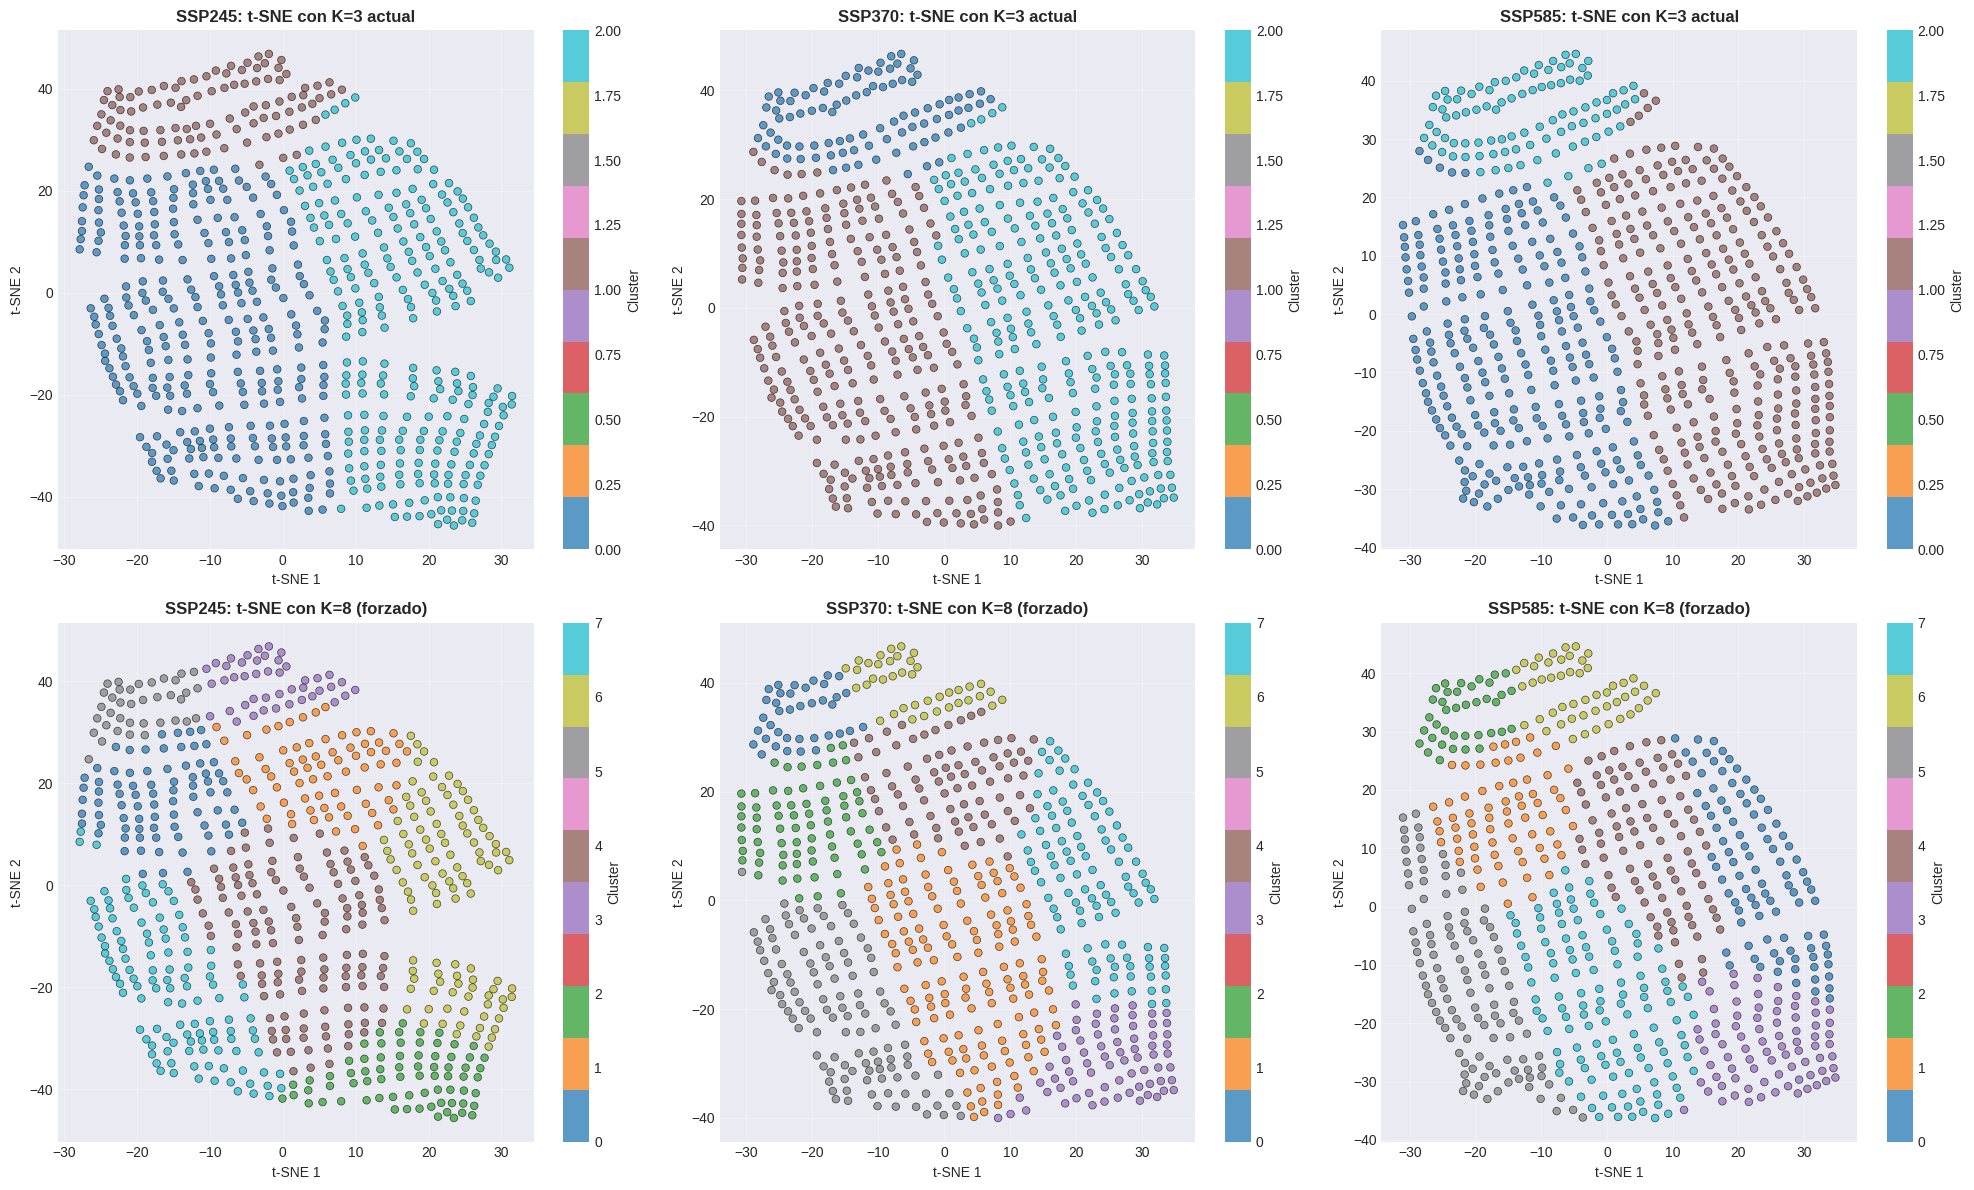


INTERPRETACIÓN:

🔍 Panel superior: Visualización con K actual (automático)
🔍 Panel inferior: Visualización con K=8 (forzado)

Observa:
- ¿Hay agrupaciones naturales visibles en el espacio t-SNE?
- ¿Los colores K=3 respetan las agrupaciones visuales?
- ¿K=8 subdivide clusters de forma coherente o fragmenta demasiado?
- Si ves 3-4 "islas" claras en t-SNE, K=8 probablemente sobre-segmenta

Decisión: 
- Si K=8 tiene silhouette razonable y crea subzonas coherentes → usar K=8
- Si K=8 fragmenta clusters naturales y silhouette baja → mantener K más bajo
- Compara distribuciones: clusters muy desbalanceados indican sobre-segmentación



In [41]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

print("="*80)
print("VISUALIZACIÓN DEL ESPACIO LATENTE")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

for scenario_idx, scenario in enumerate(SCENARIOS):
    print(f"\n📊 Procesando {scenario.upper()}...")
    
    # Obtener embeddings
    res = clustering_results[scenario]
    X_emb = res['embeddings']
    labels_k3 = res['labels']
    
    # Reducir dimensionalidad con PCA primero (acelera t-SNE)
    print(f"   Dimensiones originales: {X_emb.shape}")
    pca = PCA(n_components=min(50, X_emb.shape[1]))
    X_pca = pca.fit_transform(X_emb)
    print(f"   Varianza explicada por PCA(50): {pca.explained_variance_ratio_.sum():.3f}")
    
    # t-SNE para visualización 2D
    print(f"   Calculando t-SNE...")
    tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42, verbose=0)
    X_tsne = tsne.fit_transform(X_pca)
    
    # Panel superior: t-SNE coloreado por K=3 actual
    ax1 = axes[0, scenario_idx]
    scatter1 = ax1.scatter(X_tsne[:, 0], X_tsne[:, 1], 
                          c=labels_k3, cmap='tab10', 
                          s=30, alpha=0.7, edgecolors='k', linewidth=0.5)
    ax1.set_title(f'{scenario.upper()}: t-SNE con K={res["k"]} actual', 
                  fontsize=12, weight='bold')
    ax1.set_xlabel('t-SNE 1', fontsize=10)
    ax1.set_ylabel('t-SNE 2', fontsize=10)
    plt.colorbar(scatter1, ax=ax1, label='Cluster')
    ax1.grid(True, alpha=0.3)
    
    # Panel inferior: t-SNE con K=8 forzado (para comparar)
    kmeans_k8 = KMeans(n_clusters=8, init='k-means++', n_init=20, max_iter=500, random_state=42)
    labels_k8 = kmeans_k8.fit_predict(X_emb)
    
    ax2 = axes[1, scenario_idx]
    scatter2 = ax2.scatter(X_tsne[:, 0], X_tsne[:, 1], 
                          c=labels_k8, cmap='tab10', 
                          s=30, alpha=0.7, edgecolors='k', linewidth=0.5)
    ax2.set_title(f'{scenario.upper()}: t-SNE con K=8 (forzado)', 
                  fontsize=12, weight='bold')
    ax2.set_xlabel('t-SNE 1', fontsize=10)
    ax2.set_ylabel('t-SNE 2', fontsize=10)
    plt.colorbar(scatter2, ax=ax2, label='Cluster')
    ax2.grid(True, alpha=0.3)
    
    # Calcular silhouette para K=8
    sil_k8 = silhouette_score(X_emb, labels_k8)
    print(f"   Silhouette K={res['k']}: {res['silhouette']:.4f}")
    print(f"   Silhouette K=8: {sil_k8:.4f}")
    print(f"   Distribución K=8:")
    unique, counts = np.unique(labels_k8, return_counts=True)
    for cluster_id, count in zip(unique, counts):
        print(f"      Cluster {cluster_id}: {count} píxeles ({count/len(labels_k8)*100:.1f}%)")

plt.tight_layout()
fig_path = PLOTS_DIR / 'latent_space_tsne_comparison_k3_vs_k8.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"\n💾 Gráfico guardado: {fig_path}")
plt.show()

print("\n" + "="*80)
print("INTERPRETACIÓN:")
print("="*80)
print("""
🔍 Panel superior: Visualización con K actual (automático)
🔍 Panel inferior: Visualización con K=8 (forzado)

Observa:
- ¿Hay agrupaciones naturales visibles en el espacio t-SNE?
- ¿Los colores K=3 respetan las agrupaciones visuales?
- ¿K=8 subdivide clusters de forma coherente o fragmenta demasiado?
- Si ves 3-4 "islas" claras en t-SNE, K=8 probablemente sobre-segmenta

Decisión: 
- Si K=8 tiene silhouette razonable y crea subzonas coherentes → usar K=8
- Si K=8 fragmenta clusters naturales y silhouette baja → mantener K más bajo
- Compara distribuciones: clusters muy desbalanceados indican sobre-segmentación
""")
print("="*80)

ANÁLISIS DE CALIDAD DE CLUSTERING

📊 SSP245:
   K óptimo (Silhouette): 3
   Silhouette scores: min=0.2193, max=0.2806

📊 SSP370:
   K óptimo (Silhouette): 3
   Silhouette scores: min=0.2406, max=0.3169

📊 SSP585:
   K óptimo (Silhouette): 3
   Silhouette scores: min=0.2460, max=0.3489

💾 Gráficos guardados: /home/aninotna/magister/tesis/justh2_pipeline/plots/autoencoder_spatiotemporal/clustering_quality_analysis_conv3d.png


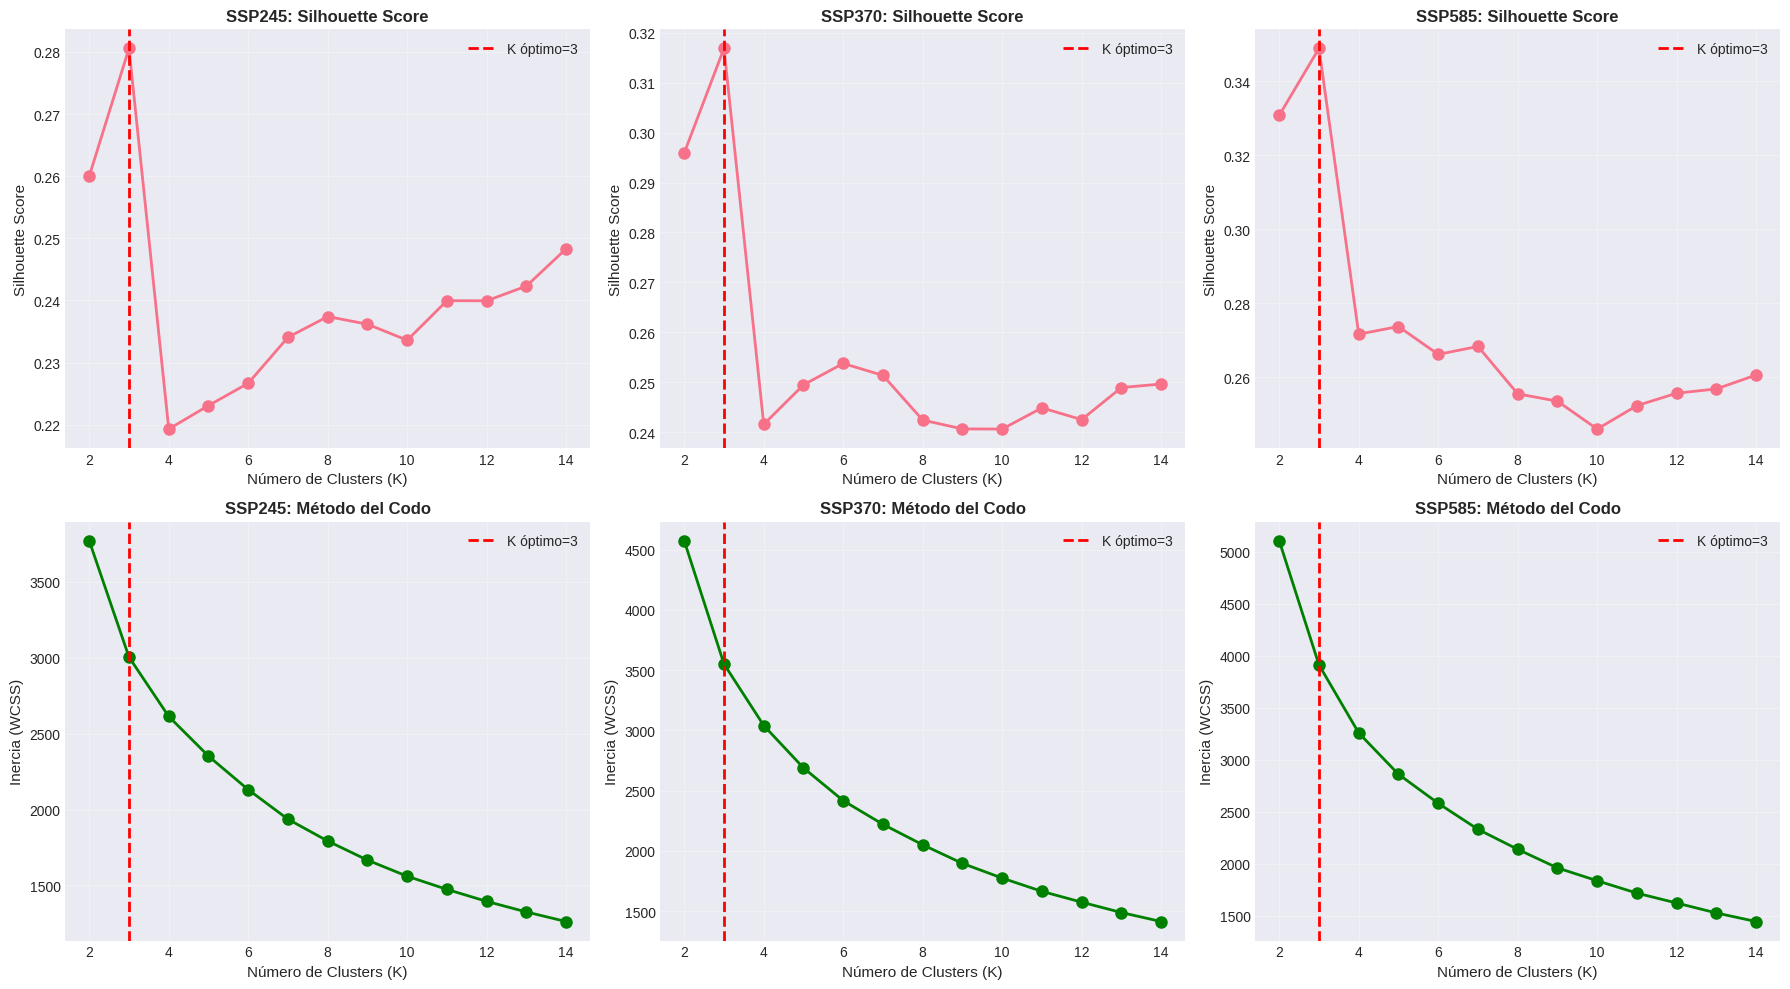


INTERPRETACIÓN:

📊 Silhouette Score (panel superior):
   - Valores cercanos a 1: Clusters bien separados
   - Valores cercanos a 0: Clusters solapados
   - Si K=3 tiene el máximo, los embeddings tienen 3 grupos naturales

📉 Método del Codo (panel inferior):
   - Buscar el "codo" donde la inercia deja de decrecer rápidamente
   - Si el codo está en K=3-4, confirma que hay pocos grupos naturales

⚠️  Si K=3 es consistente pero esperabas más:
   1. Los embeddings Conv3D son muy homogéneos
   2. La variabilidad espaciotemporal es baja en el Valle
   3. Los 3 modelos concatenados generan redundancia



In [40]:
print("="*80)
print("ANÁLISIS DE CALIDAD DE CLUSTERING")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for scenario_idx, scenario in enumerate(SCENARIOS):
    print(f"\n📊 {scenario.upper()}:")
    
    # Obtener datos guardados
    res = clustering_results[scenario]
    X_emb = res['embeddings']
    best_k = res['k']
    
    # Re-calcular para todos los K (para graficar)
    K_RANGE_PLOT = range(2, 15)
    silhouette_scores = []
    inertias = []
    
    for k in K_RANGE_PLOT:
        kmeans = KMeans(n_clusters=k, init='k-means++', n_init=20, max_iter=500, random_state=42)
        labels = kmeans.fit_predict(X_emb)
        
        if k > 1:
            sil_score = silhouette_score(X_emb, labels)
        else:
            sil_score = 0
        
        silhouette_scores.append(sil_score)
        inertias.append(kmeans.inertia_)
    
    print(f"   K óptimo (Silhouette): {best_k}")
    print(f"   Silhouette scores: min={min(silhouette_scores):.4f}, max={max(silhouette_scores):.4f}")
    
    # Panel superior: Silhouette Score
    ax1 = axes[0, scenario_idx]
    ax1.plot(K_RANGE_PLOT, silhouette_scores, 'o-', linewidth=2, markersize=8)
    ax1.axvline(best_k, color='red', linestyle='--', linewidth=2, label=f'K óptimo={best_k}')
    ax1.set_xlabel('Número de Clusters (K)', fontsize=11)
    ax1.set_ylabel('Silhouette Score', fontsize=11)
    ax1.set_title(f'{scenario.upper()}: Silhouette Score', fontsize=12, weight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # Panel inferior: Elbow Method (Inercia)
    ax2 = axes[1, scenario_idx]
    ax2.plot(K_RANGE_PLOT, inertias, 'o-', linewidth=2, markersize=8, color='green')
    ax2.axvline(best_k, color='red', linestyle='--', linewidth=2, label=f'K óptimo={best_k}')
    ax2.set_xlabel('Número de Clusters (K)', fontsize=11)
    ax2.set_ylabel('Inercia (WCSS)', fontsize=11)
    ax2.set_title(f'{scenario.upper()}: Método del Codo', fontsize=12, weight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend()

plt.tight_layout()
fig_path = PLOTS_DIR / 'clustering_quality_analysis_conv3d.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"\n💾 Gráficos guardados: {fig_path}")
plt.show()

print("\n" + "="*80)
print("INTERPRETACIÓN:")
print("="*80)
print("""
📊 Silhouette Score (panel superior):
   - Valores cercanos a 1: Clusters bien separados
   - Valores cercanos a 0: Clusters solapados
   - Si K=3 tiene el máximo, los embeddings tienen 3 grupos naturales

📉 Método del Codo (panel inferior):
   - Buscar el "codo" donde la inercia deja de decrecer rápidamente
   - Si el codo está en K=3-4, confirma que hay pocos grupos naturales

⚠️  Si K=3 es consistente pero esperabas más:
   1. Los embeddings Conv3D son muy homogéneos
   2. La variabilidad espaciotemporal es baja en el Valle
   3. Los 3 modelos concatenados generan redundancia
""")
print("="*80)

## Paso 11: Índice de resiliencia y Moran's I

In [42]:
print("="*80)
print("CÁLCULO DE RESILIENCIA")
print("="*80)

resilience_by_scenario = {}

for scenario in SCENARIOS:
    print(f"\n📊 {scenario.upper()}:")
    
    kmeans = clustering_results[scenario]['kmeans']
    labels = clustering_results[scenario]['labels']
    X_emb = clustering_results[scenario]['embeddings']
    centroids = kmeans.cluster_centers_
    
    # Distancia al centroide
    distances = np.zeros(len(X_emb))
    for i in range(len(X_emb)):
        cluster_id = labels[i]
        centroid = centroids[cluster_id]
        distances[i] = np.linalg.norm(X_emb[i] - centroid)
    
    # Normalizar
    distances_norm = (distances - distances.min()) / (distances.max() - distances.min())
    resilience = 1 - distances_norm
    
    print(f"   Resiliencia: mean={resilience.mean():.4f}, std={resilience.std():.4f}")
    
    resilience_by_scenario[scenario] = {
        'resilience': resilience,
        'labels': labels
    }

print("\n✅ Resiliencia calculada")
print("="*80)

CÁLCULO DE RESILIENCIA

📊 SSP245:
   Resiliencia: mean=0.6574, std=0.1599

📊 SSP370:
   Resiliencia: mean=0.6936, std=0.1469

📊 SSP585:
   Resiliencia: mean=0.6973, std=0.1605

✅ Resiliencia calculada


In [36]:
def calculate_morans_i(values, mask, grid_shape):
    """Calcula Moran's I para autocorrelación espacial"""
    n_lat, n_lon = grid_shape
    
    grid_2d = np.full(grid_shape, np.nan)
    grid_2d[mask] = values
    
    numerator_sum = 0
    denominator_sum = 0
    weight_sum = 0
    
    mean_val = np.nanmean(grid_2d)
    n_valid = 0
    
    for i in range(n_lat):
        for j in range(n_lon):
            if not mask[i, j]:
                continue
            
            val_i = grid_2d[i, j]
            n_valid += 1
            
            neighbors = []
            if i > 0 and mask[i-1, j]:
                neighbors.append(grid_2d[i-1, j])
            if i < n_lat-1 and mask[i+1, j]:
                neighbors.append(grid_2d[i+1, j])
            if j > 0 and mask[i, j-1]:
                neighbors.append(grid_2d[i, j-1])
            if j < n_lon-1 and mask[i, j+1]:
                neighbors.append(grid_2d[i, j+1])
            
            for val_j in neighbors:
                numerator_sum += (val_i - mean_val) * (val_j - mean_val)
                weight_sum += 1
            
            denominator_sum += (val_i - mean_val) ** 2
    
    if weight_sum > 0 and denominator_sum > 0:
        morans_i = (n_valid / weight_sum) * (numerator_sum / denominator_sum)
    else:
        morans_i = 0.0
    
    return morans_i

print("="*80)
print("VALIDACIÓN: MORAN'S I")
print("="*80)

morans_results = {}

for scenario in SCENARIOS:
    resilience = resilience_by_scenario[scenario]['resilience']
    
    morans_i = calculate_morans_i(resilience, MASK, grid_shape)
    
    if morans_i > 0.3:
        status = "✅ EXCELENTE"
    elif morans_i > 0.1:
        status = "✓ BUENO"
    else:
        status = "⚠️  MEJORABLE"
    
    print(f"\n{scenario.upper()}: Moran's I = {morans_i:.4f} ({status})")
    
    morans_results[scenario] = morans_i

print("\n" + "="*80)
print(f"📊 Promedio Moran's I: {np.mean(list(morans_results.values())):.4f}")
print("="*80)

VALIDACIÓN: MORAN'S I

SSP245: Moran's I = 0.7885 (✅ EXCELENTE)

SSP370: Moran's I = 0.8035 (✅ EXCELENTE)

SSP585: Moran's I = 0.8298 (✅ EXCELENTE)

📊 Promedio Moran's I: 0.8072


## Paso 12: VALIDACIÓN CRÍTICA - Variables Discriminantes

**Este es el test definitivo:** ¿Las variables discriminantes ahora son las variables base (sin sufijos _YYYY)?

Esperamos ver:
- ✅ "climate_cdd_decadal_mean"
- ✅ "climate_rx5day_decadal_std"
- ❌ NO "climate_cdd_decadal_mean_2040"

In [27]:
print("="*80)
print("ANÁLISIS DE VARIABLES DISCRIMINANTES")
print("="*80)

# Cargar datos originales por escenario para ANOVA
from scipy.stats import f_oneway

# Necesitamos los datos originales organizados por píxel
# Ya los tenemos en X_temporal_by_scenario

print("\n🔍 Calculando F-statistic (ANOVA) por variable base...")

for scenario_idx, scenario in enumerate(SCENARIOS):
    print(f"\n{'='*80}")
    print(f"📊 {scenario.upper()}")
    print(f"{'='*80}")
    
    X_temporal = X_temporal_by_scenario[scenario][:n_pixels_valid]  # (n_pixels, time, vars)
    labels = resilience_by_scenario[scenario]['labels']
    
    # Promediar sobre tiempo para cada píxel
    X_pixel_avg = X_temporal.mean(axis=1)  # (n_pixels, vars_base)
    
    n_clusters = len(np.unique(labels))
    n_vars = X_pixel_avg.shape[1]
    
    f_stats = []
    p_values = []
    
    for var_idx in range(n_vars):
        # Datos de la variable por cluster
        groups = [X_pixel_avg[labels == c, var_idx] for c in range(n_clusters)]
        
        # ANOVA
        f_stat, p_val = f_oneway(*groups)
        f_stats.append(f_stat)
        p_values.append(p_val)
    
    # Ordenar por F-statistic
    f_stats = np.array(f_stats)
    top_indices = np.argsort(f_stats)[::-1][:20]
    
    print(f"\n🎯 Top 20 variables discriminantes (sin sufijos temporales):")
    print("="*70)
    print(f"{'Variable':<50} {'F-statistic':>15}")
    print("="*70)
    
    for rank, idx in enumerate(top_indices, 1):
        var_name = var_base_names[idx]
        f_stat = f_stats[idx]
        print(f"{rank:2}. {var_name:<48} {f_stat:>15.2f}")
    
    print("="*70)

print("\n✅ Análisis completado")
print("="*80)

ANÁLISIS DE VARIABLES DISCRIMINANTES

🔍 Calculando F-statistic (ANOVA) por variable base...

📊 SSP245

🎯 Top 20 variables discriminantes (sin sufijos temporales):
Variable                                               F-statistic
 1. calliope_h2_prod_ton                                        3.35
 2. calliope_cf_mean                                            3.31
 3. climate_tmin_mean_decadal_std                               3.17
 4. calliope_lcoh_usd_kg                                        3.11
 5. landuse_water_glacier                                       2.78
 6. landuse_restricted                                          2.35
 7. climate_cdd_decadal_std                                     2.23
 8. climate_cdd_decadal_max                                     2.15
 9. calliope_cap_electrolyzer_mw                                1.89
10. conflict_density                                            1.70
11. climate_sdii_decadal_min                                    1.49
12. climate

## Resumen de resultados esperados

**Si el modelo funciona correctamente, deberíamos ver:**

1. **Moran's I > 0.3** para todos los escenarios (coherencia espacial)
2. **Variables discriminantes SIN sufijos temporales:**
   - ✅ "climate_cdd_decadal_mean"
   - ✅ "climate_rx5day_decadal_max"
   - ✅ "climate_tmax_mean_decadal_std"
3. **Embeddings de menor dimensión** que capturen patrones evolutivos temporales
4. **Clustering con sentido geográfico** (visualización en mapas)

**Comparación con 03c:**
- 03c: Variables como "climate_cdd_decadal_mean_2040" (fragmentadas)
- 03d: Variables como "climate_cdd_decadal_mean" (integradas)


## Guardar resultados

In [28]:
print("="*80)
print("GUARDANDO RESULTADOS")
print("="*80)

# Guardar clustering results
output_file = RESULTS_DIR / 'clustering_results_conv3d_spatiotemporal.pkl'

results_to_save = {
    'clustering_results': clustering_results,
    'resilience_by_scenario': resilience_by_scenario,
    'morans_results': morans_results,
    'var_base_names': var_base_names,
    'timesteps': timesteps,
    'embeddings_concat_by_scenario': embeddings_concat_by_scenario,
    'metadata': {
        'grid_shape': grid_shape,
        'n_pixels_valid': n_pixels_valid,
        'models_config': MODELS_CONFIG,
        'train_config': TRAIN_CONFIG
    }
}

with open(output_file, 'wb') as f:
    pickle.dump(results_to_save, f)

print(f"\n💾 Resultados guardados en: {output_file}")
print("\n✅ Pipeline Conv3D Espaciotemporal completado!")
print("="*80)

GUARDANDO RESULTADOS

💾 Resultados guardados en: /home/aninotna/magister/tesis/justh2_pipeline/data/autoencoder_results/clustering_results_conv3d_spatiotemporal.pkl

✅ Pipeline Conv3D Espaciotemporal completado!


## Visualización de Clusters y Resiliencia en Mapas

In [29]:
print("="*80)
print("PREPARANDO DATOS PARA VISUALIZACIÓN")
print("="*80)

# Crear arrays 2D para clusters y resiliencia
cluster_maps = {}
resilience_maps = {}

for scenario in SCENARIOS:
    print(f"\n📊 {scenario.upper()}:")
    
    labels = resilience_by_scenario[scenario]['labels']
    resilience = resilience_by_scenario[scenario]['resilience']
    
    # Crear grids 2D
    cluster_2d = np.full((n_lat, n_lon), np.nan)
    resilience_2d = np.full((n_lat, n_lon), np.nan)
    
    # Llenar píxeles válidos
    cluster_2d[MASK] = labels
    resilience_2d[MASK] = resilience
    
    # Flipud para orientación correcta (sur arriba)
    cluster_2d_flipped = np.flipud(cluster_2d)
    resilience_2d_flipped = np.flipud(resilience_2d)
    
    cluster_maps[scenario] = cluster_2d_flipped
    resilience_maps[scenario] = resilience_2d_flipped
    
    print(f"   Clusters: {cluster_2d_flipped.shape}")
    print(f"   Resiliencia: {resilience_2d_flipped.shape}")
    print(f"   N clusters: {len(np.unique(labels))}")

print("\n✅ Datos preparados para visualización")
print("="*80)

PREPARANDO DATOS PARA VISUALIZACIÓN

📊 SSP245:
   Clusters: (24, 42)
   Resiliencia: (24, 42)
   N clusters: 3

📊 SSP370:
   Clusters: (24, 42)
   Resiliencia: (24, 42)
   N clusters: 3

📊 SSP585:
   Clusters: (24, 42)
   Resiliencia: (24, 42)
   N clusters: 3

✅ Datos preparados para visualización


MAPA 1: CLUSTERS POR ESCENARIO (3 PANELES)

💾 Mapa guardado: /home/aninotna/magister/tesis/justh2_pipeline/plots/autoencoder_spatiotemporal/clusters_by_scenario_conv3d.png


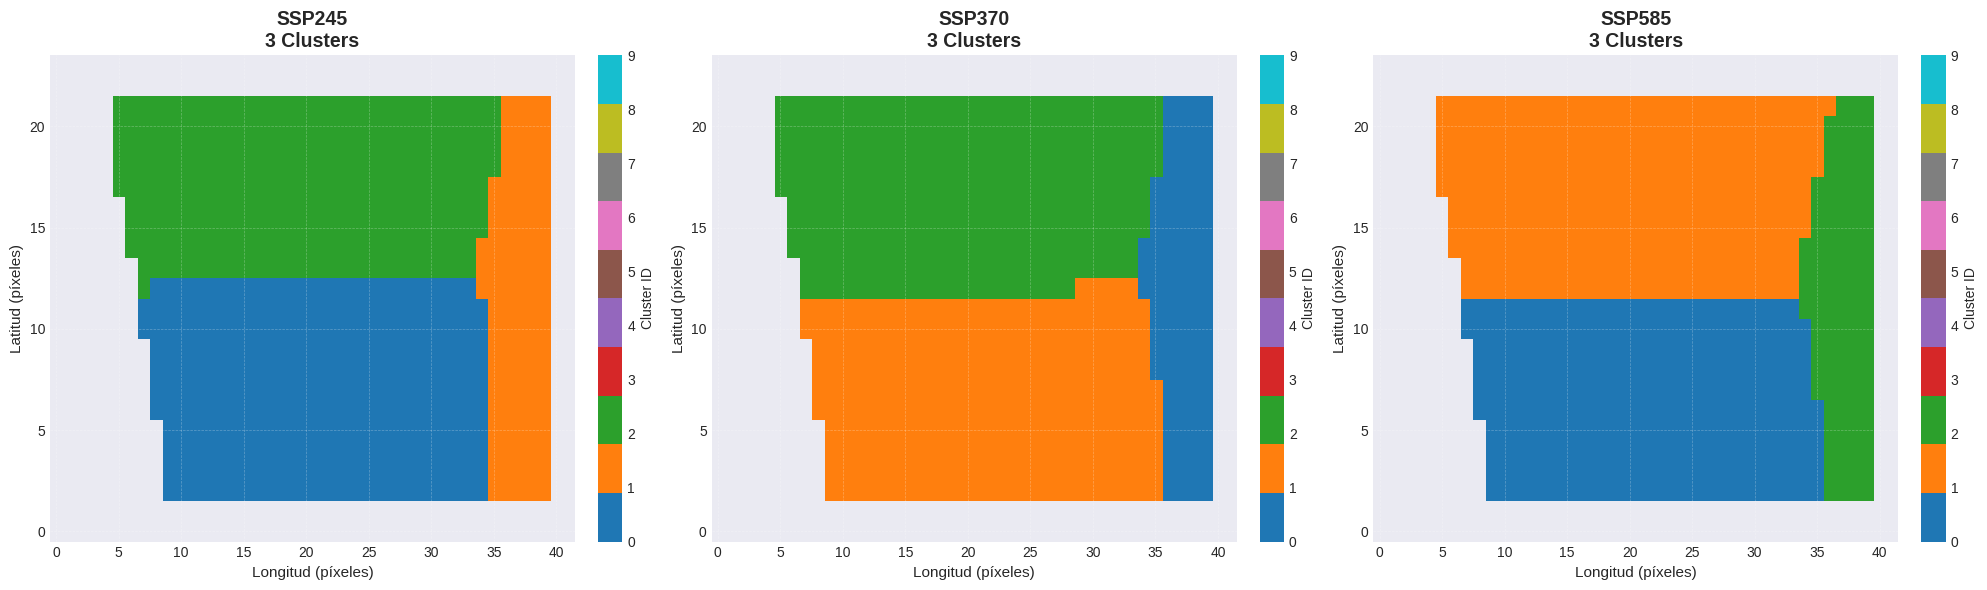

In [44]:
print("="*80)
print("MAPA 1: CLUSTERS POR ESCENARIO (3 PANELES)")
print("="*80)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, scenario in enumerate(SCENARIOS):
    ax = axes[idx]
    
    cluster_2d = cluster_maps[scenario]
    n_clusters = len(np.unique(resilience_by_scenario[scenario]['labels']))
    
    # Plotear clusters
    im = ax.imshow(
        cluster_2d,
        cmap='tab10',
        aspect='auto',
        origin='lower',
        vmin=0,
        vmax=9,
        interpolation='nearest'
    )
    
    # Configuración
    ax.set_title(f'{scenario.upper()}\n{n_clusters} Clusters', fontsize=14, weight='bold')
    ax.set_xlabel('Longitud (píxeles)', fontsize=11)
    ax.set_ylabel('Latitud (píxeles)', fontsize=11)
    
    # Grid
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    
    # Colorbar
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Cluster ID', fontsize=10)

plt.tight_layout()
fig_path = PLOTS_DIR / 'clusters_by_scenario_conv3d.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"\n💾 Mapa guardado: {fig_path}")
plt.show()

print("="*80)

MAPA 2: RESILIENCIA POR ESCENARIO (3 PANELES)

💾 Mapa guardado: /home/aninotna/magister/tesis/justh2_pipeline/plots/autoencoder_spatiotemporal/resilience_by_scenario_conv3d.png


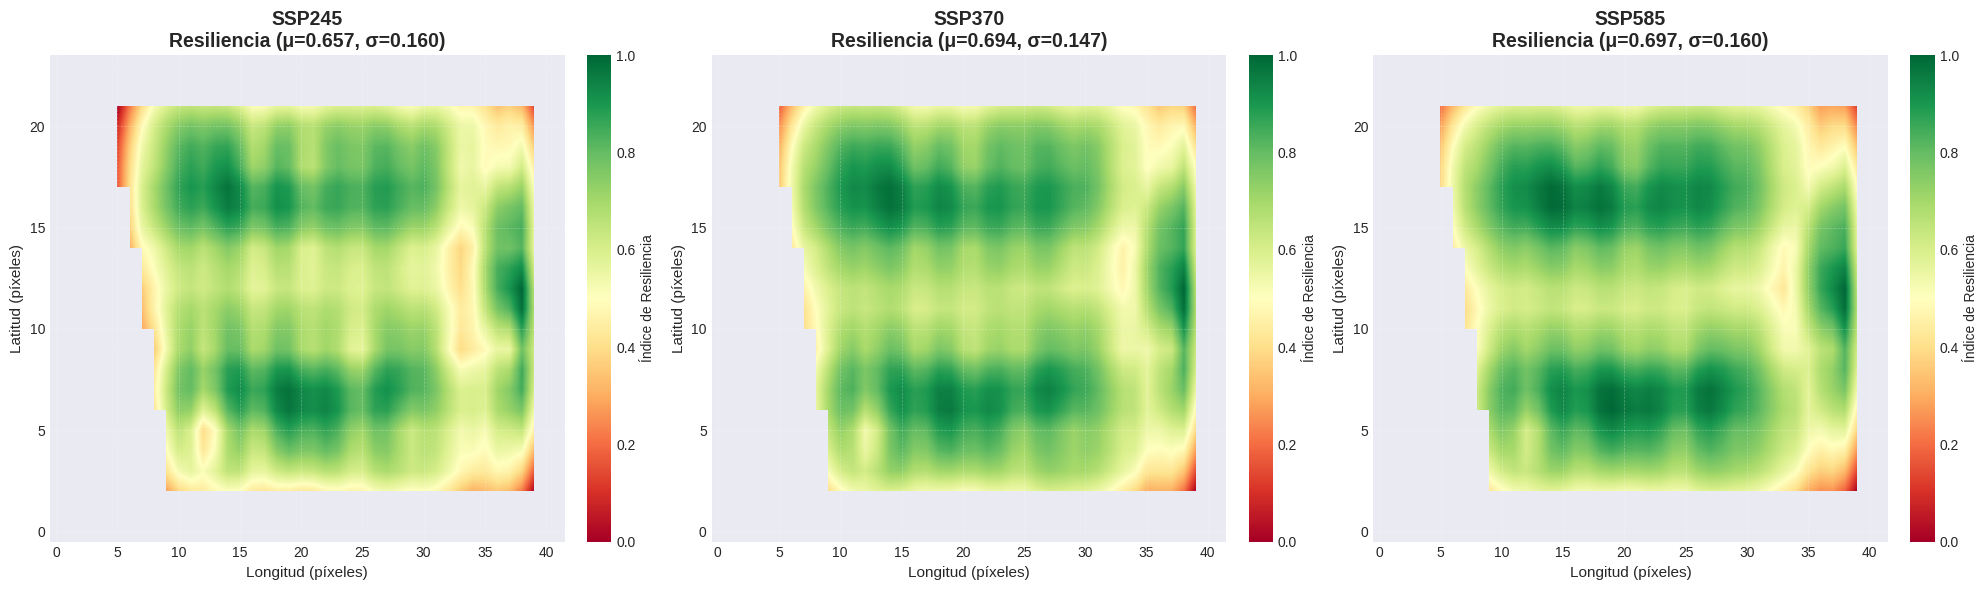

In [31]:
print("="*80)
print("MAPA 2: RESILIENCIA POR ESCENARIO (3 PANELES)")
print("="*80)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, scenario in enumerate(SCENARIOS):
    ax = axes[idx]
    
    resilience_2d = resilience_maps[scenario]
    resilience_vals = resilience_by_scenario[scenario]['resilience']
    
    # Plotear resiliencia
    im = ax.imshow(
        resilience_2d,
        cmap='RdYlGn',  # Rojo=baja, Verde=alta
        aspect='auto',
        origin='lower',
        vmin=0,
        vmax=1,
        interpolation='bilinear'
    )
    
    # Configuración
    ax.set_title(
        f'{scenario.upper()}\nResiliencia (μ={resilience_vals.mean():.3f}, σ={resilience_vals.std():.3f})',
        fontsize=14,
        weight='bold'
    )
    ax.set_xlabel('Longitud (píxeles)', fontsize=11)
    ax.set_ylabel('Latitud (píxeles)', fontsize=11)
    
    # Grid
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    
    # Colorbar
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Índice de Resiliencia', fontsize=10)

plt.tight_layout()
fig_path = PLOTS_DIR / 'resilience_by_scenario_conv3d.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"\n💾 Mapa guardado: {fig_path}")
plt.show()

print("="*80)

MAPA 3: CLUSTERS + RESILIENCIA SUPERPUESTOS (SSP370)

💾 Mapa guardado: /home/aninotna/magister/tesis/justh2_pipeline/plots/autoencoder_spatiotemporal/clusters_resilience_overlay_ssp370_conv3d.png


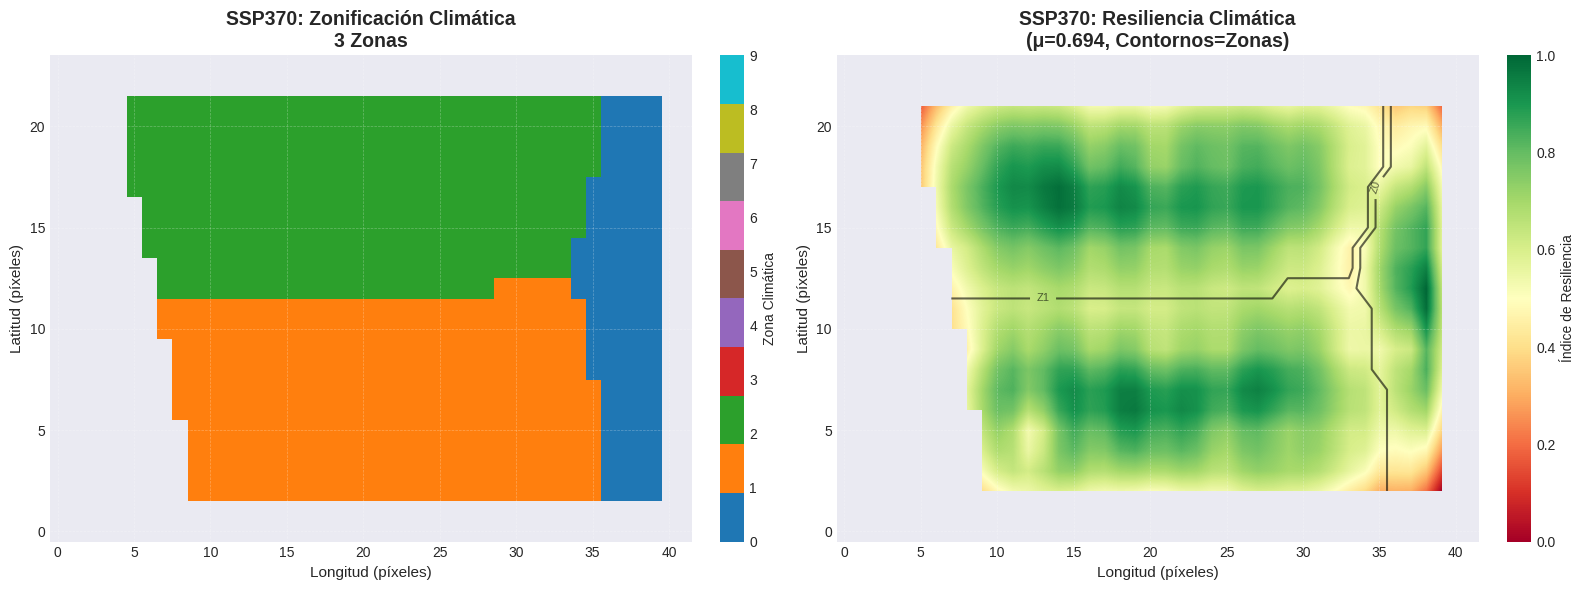

In [32]:
print("="*80)
print("MAPA 3: CLUSTERS + RESILIENCIA SUPERPUESTOS (SSP370)")
print("="*80)

# Usar SSP370 como ejemplo
scenario_example = 'ssp370'

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel izquierdo: Clusters
ax1 = axes[0]
cluster_2d = cluster_maps[scenario_example]
n_clusters = len(np.unique(resilience_by_scenario[scenario_example]['labels']))

im1 = ax1.imshow(
    cluster_2d,
    cmap='tab10',
    aspect='auto',
    origin='lower',
    vmin=0,
    vmax=9,
    interpolation='nearest'
)
ax1.set_title(f'{scenario_example.upper()}: Zonificación Climática\n{n_clusters} Zonas', fontsize=14, weight='bold')
ax1.set_xlabel('Longitud (píxeles)', fontsize=11)
ax1.set_ylabel('Latitud (píxeles)', fontsize=11)
ax1.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

cbar1 = plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
cbar1.set_label('Zona Climática', fontsize=10)

# Panel derecho: Resiliencia con contornos de clusters
ax2 = axes[1]
resilience_2d = resilience_maps[scenario_example]
resilience_vals = resilience_by_scenario[scenario_example]['resilience']

im2 = ax2.imshow(
    resilience_2d,
    cmap='RdYlGn',
    aspect='auto',
    origin='lower',
    vmin=0,
    vmax=1,
    interpolation='bilinear'
)

# Superponer contornos de clusters
contours = ax2.contour(
    cluster_2d,
    levels=np.arange(n_clusters) + 0.5,
    colors='black',
    linewidths=1.5,
    alpha=0.6
)
ax2.clabel(contours, inline=True, fontsize=8, fmt='Z%d')

ax2.set_title(
    f'{scenario_example.upper()}: Resiliencia Climática\n(μ={resilience_vals.mean():.3f}, Contornos=Zonas)',
    fontsize=14,
    weight='bold'
)
ax2.set_xlabel('Longitud (píxeles)', fontsize=11)
ax2.set_ylabel('Latitud (píxeles)', fontsize=11)
ax2.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

cbar2 = plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
cbar2.set_label('Índice de Resiliencia', fontsize=10)

plt.tight_layout()
fig_path = PLOTS_DIR / f'clusters_resilience_overlay_{scenario_example}_conv3d.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"\n💾 Mapa guardado: {fig_path}")
plt.show()

print("="*80)

MAPA 4: MAPA GEOGRÁFICO CON COORDENADAS REALES


/home/aninotna/.conda/envs/tsenv/lib/python3.11/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)



💾 Mapa geográfico guardado: /home/aninotna/magister/tesis/justh2_pipeline/plots/autoencoder_spatiotemporal/geographic_map_ssp370_conv3d.png


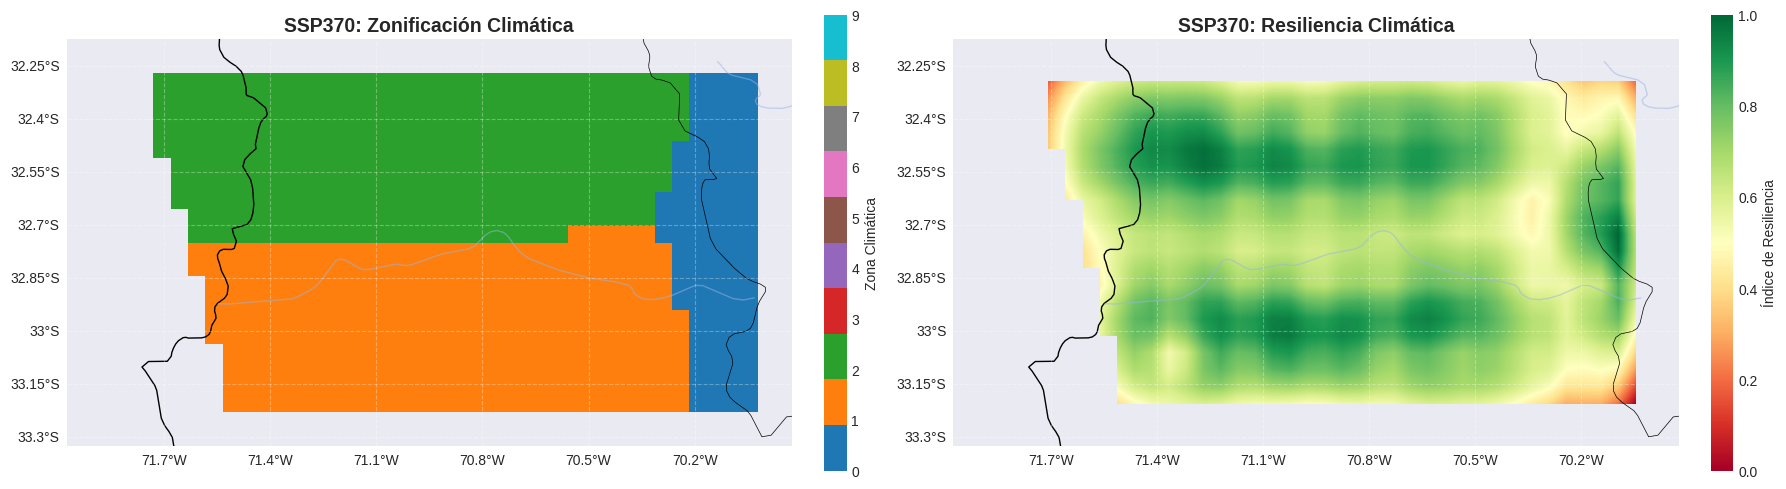

In [33]:
print("="*80)
print("MAPA 4: MAPA GEOGRÁFICO CON COORDENADAS REALES")
print("="*80)

# Verificar si cartopy está disponible
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    has_cartopy = True
except ImportError:
    has_cartopy = False
    print("⚠️  Cartopy no disponible. Usando matplotlib estándar.")

scenario_example = 'ssp370'

if has_cartopy:
    # MAPA CON CARTOPY (proyección geográfica)
    fig, axes = plt.subplots(
        1, 2,
        figsize=(18, 6),
        subplot_kw={'projection': ccrs.PlateCarree()}
    )
    
    # Panel izquierdo: Clusters
    ax1 = axes[0]
    cluster_2d = cluster_maps[scenario_example]
    
    # Extent geográfico (lon_min, lon_max, lat_min, lat_max)
    extent = [lon_coords.min(), lon_coords.max(), lat_coords.min(), lat_coords.max()]
    
    im1 = ax1.imshow(
        cluster_2d,
        cmap='tab10',
        extent=extent,
        origin='lower',
        transform=ccrs.PlateCarree(),
        interpolation='nearest',
        vmin=0,
        vmax=9
    )
    
    # Features geográficos
    ax1.coastlines(resolution='10m', linewidth=1)
    ax1.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax1.add_feature(cfeature.RIVERS, alpha=0.5)
    
    # Gridlines
    gl1 = ax1.gridlines(draw_labels=True, alpha=0.3, linestyle='--')
    gl1.top_labels = False
    gl1.right_labels = False
    
    ax1.set_title(f'{scenario_example.upper()}: Zonificación Climática', fontsize=14, weight='bold')
    
    cbar1 = plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04, shrink=0.8)
    cbar1.set_label('Zona Climática', fontsize=10)
    
    # Panel derecho: Resiliencia
    ax2 = axes[1]
    resilience_2d = resilience_maps[scenario_example]
    
    im2 = ax2.imshow(
        resilience_2d,
        cmap='RdYlGn',
        extent=extent,
        origin='lower',
        transform=ccrs.PlateCarree(),
        interpolation='bilinear',
        vmin=0,
        vmax=1
    )
    
    # Features geográficos
    ax2.coastlines(resolution='10m', linewidth=1)
    ax2.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax2.add_feature(cfeature.RIVERS, alpha=0.5)
    
    # Gridlines
    gl2 = ax2.gridlines(draw_labels=True, alpha=0.3, linestyle='--')
    gl2.top_labels = False
    gl2.right_labels = False
    
    ax2.set_title(f'{scenario_example.upper()}: Resiliencia Climática', fontsize=14, weight='bold')
    
    cbar2 = plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04, shrink=0.8)
    cbar2.set_label('Índice de Resiliencia', fontsize=10)
    
    plt.tight_layout()
    fig_path = PLOTS_DIR / f'geographic_map_{scenario_example}_conv3d.png'
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    print(f"\n💾 Mapa geográfico guardado: {fig_path}")
    plt.show()

else:
    # FALLBACK: Mapa con coordenadas en ejes
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    extent = [lon_coords.min(), lon_coords.max(), lat_coords.min(), lat_coords.max()]
    
    # Panel izquierdo: Clusters
    ax1 = axes[0]
    cluster_2d = cluster_maps[scenario_example]
    
    im1 = ax1.imshow(
        cluster_2d,
        cmap='tab10',
        extent=extent,
        origin='lower',
        aspect='auto',
        interpolation='nearest',
        vmin=0,
        vmax=9
    )
    
    ax1.set_title(f'{scenario_example.upper()}: Zonificación Climática', fontsize=14, weight='bold')
    ax1.set_xlabel('Longitud (°W)', fontsize=11)
    ax1.set_ylabel('Latitud (°S)', fontsize=11)
    ax1.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    
    cbar1 = plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
    cbar1.set_label('Zona Climática', fontsize=10)
    
    # Panel derecho: Resiliencia
    ax2 = axes[1]
    resilience_2d = resilience_maps[scenario_example]
    
    im2 = ax2.imshow(
        resilience_2d,
        cmap='RdYlGn',
        extent=extent,
        origin='lower',
        aspect='auto',
        interpolation='bilinear',
        vmin=0,
        vmax=1
    )
    
    ax2.set_title(f'{scenario_example.upper()}: Resiliencia Climática', fontsize=14, weight='bold')
    ax2.set_xlabel('Longitud (°W)', fontsize=11)
    ax2.set_ylabel('Latitud (°S)', fontsize=11)
    ax2.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    
    cbar2 = plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
    cbar2.set_label('Índice de Resiliencia', fontsize=10)
    
    plt.tight_layout()
    fig_path = PLOTS_DIR / f'geographic_map_{scenario_example}_conv3d.png'
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    print(f"\n💾 Mapa con coordenadas guardado: {fig_path}")
    plt.show()

print("="*80)

In [34]:
print("="*80)
print("ESTADÍSTICOS DE RESOLUCIÓN ESPACIAL")
print("="*80)

print(f"\n📐 Resolución espacial del grid:")
print(f"   Grid shape: {n_lat} × {n_lon} = {n_lat * n_lon} píxeles totales")
print(f"   Píxeles válidos: {n_pixels_valid} ({n_pixels_valid/(n_lat*n_lon)*100:.1f}%)")

# Calcular resolución en km (aproximado)
lat_range = lat_coords.max() - lat_coords.min()
lon_range = lon_coords.max() - lon_coords.min()

# Aproximación: 1° lat ≈ 111 km, 1° lon ≈ 111 * cos(lat) km
lat_mean = lat_coords.mean()
km_per_deg_lat = 111
km_per_deg_lon = 111 * np.cos(np.radians(abs(lat_mean)))

lat_resolution_km = (lat_range / n_lat) * km_per_deg_lat
lon_resolution_km = (lon_range / n_lon) * km_per_deg_lon

print(f"\n🌍 Coordenadas geográficas:")
print(f"   Latitud: {lat_coords.min():.2f}° a {lat_coords.max():.2f}° (rango: {lat_range:.2f}°)")
print(f"   Longitud: {lon_coords.min():.2f}° a {lon_coords.max():.2f}° (rango: {lon_range:.2f}°)")

print(f"\n📏 Resolución espacial:")
print(f"   Latitud: {lat_resolution_km:.2f} km por píxel")
print(f"   Longitud: {lon_resolution_km:.2f} km por píxel")
print(f"   Área aprox. por píxel: {lat_resolution_km * lon_resolution_km:.2f} km²")

# Área total
total_area_km2 = lat_range * km_per_deg_lat * lon_range * km_per_deg_lon
valid_area_km2 = total_area_km2 * (n_pixels_valid / (n_lat * n_lon))

print(f"\n🗺️  Área de estudio:")
print(f"   Área total del grid: {total_area_km2:.0f} km²")
print(f"   Área válida (Valle de Aconcagua): {valid_area_km2:.0f} km²")

print("\n" + "="*80)
print("RESUMEN DE COHERENCIA ESPACIAL")
print("="*80)

print(f"\n📊 Moran's I por escenario:")
for scenario in SCENARIOS:
    mi = morans_results[scenario]
    if mi > 0.3:
        emoji = "✅"
        status = "EXCELENTE"
    elif mi > 0.1:
        emoji = "✓"
        status = "BUENO"
    else:
        emoji = "⚠️"
        status = "MEJORABLE"
    
    n_clusters = len(np.unique(resilience_by_scenario[scenario]['labels']))
    
    print(f"   {emoji} {scenario.upper()}: Moran's I = {mi:.4f} ({status})")
    print(f"      → {n_clusters} zonas climáticas identificadas")

mean_morans = np.mean(list(morans_results.values()))
print(f"\n🎯 Promedio Moran's I: {mean_morans:.4f}")

if mean_morans > 0.3:
    print("   ✅ COHERENCIA ESPACIAL EXCELENTE")
    print("   Los clusters reflejan zonificación geográfica real")
elif mean_morans > 0.1:
    print("   ✓ COHERENCIA ESPACIAL ACEPTABLE")
    print("   Los clusters tienen cierta estructura geográfica")
else:
    print("   ⚠️  COHERENCIA ESPACIAL BAJA")
    print("   Los clusters no reflejan bien la geografía")

print("\n" + "="*80)

ESTADÍSTICOS DE RESOLUCIÓN ESPACIAL

📐 Resolución espacial del grid:
   Grid shape: 24 × 42 = 1008 píxeles totales
   Píxeles válidos: 661 (65.6%)

🌍 Coordenadas geográficas:
   Latitud: -33.33° a -32.17° (rango: 1.15°)
   Longitud: -71.97° a -69.93° (rango: 2.05°)

📏 Resolución espacial:
   Latitud: 5.32 km por píxel
   Longitud: 4.56 km por píxel
   Área aprox. por píxel: 24.24 km²

🗺️  Área de estudio:
   Área total del grid: 24429 km²
   Área válida (Valle de Aconcagua): 16020 km²

RESUMEN DE COHERENCIA ESPACIAL

📊 Moran's I por escenario:
   ✅ SSP245: Moran's I = 0.7885 (EXCELENTE)
      → 3 zonas climáticas identificadas
   ✅ SSP370: Moran's I = 0.8035 (EXCELENTE)
      → 3 zonas climáticas identificadas
   ✅ SSP585: Moran's I = 0.8298 (EXCELENTE)
      → 3 zonas climáticas identificadas

🎯 Promedio Moran's I: 0.8072
   ✅ COHERENCIA ESPACIAL EXCELENTE
   Los clusters reflejan zonificación geográfica real

